# Encoding analysis: wilbur20210512

**Contents**

1. [Setup](#Setup)
2. [Single-variable models](#Single-variable-models)
   - Null - Trial type - Choice - Speed - Position - Trial progress
3. [Combined models](#Combined-models)
   - Full - Temporal - Choice full - Choice temporal
4. [Model comparison](#Model-comparison)
   - Single-variable AIC/LRT - Drop-one & LRT


In [2]:
import os
import datajoint as dj
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir("..")
    
%matplotlib qt
%config InlineBackend.figure_format = 'retina'
sns.set_context("talk")

%reload_ext autoreload
%autoreload 2
pd.options.display.max_rows = 600
pd.set_option('display.float_format', lambda x: '%.9f' % x)

dj.config['display.limit'] = 10**3  

In [22]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats         
from scipy.stats import chi2 
from functools import partial
from notebooks.encoding_utils import *
from notebooks.spike_visualisation import *

## Setup

### Load data

In [55]:
base_dir = CONFIG["base_dir"]
BIN_SIZE = CONFIG["bin_size"]

data = load_and_prepare_data()
cov_df_correct = data["cov_df_correct"]
spike_counts_correct = data["spike_counts_correct"]
cov_df_common        = data["cov_df_common"] #covariate dataframe, maked for correct outbound and inbound trials, runs only
cov_df_out_common    = data["cov_df_out_common"] # only outbound trials, for choice analysis
spike_counts_common  = data["spike_counts_common"]
spike_counts_out_common = data["spike_counts_out_common"]
unit_ids             = data["unit_ids"]
bin_centers          = data["bin_centers"]
sp                   = data["scaling_params"]
pos_min_val, pos_max_val   = sp["pos_min"], sp["pos_max"]
speed_min_val, speed_max_val = sp["speed_min"], sp["speed_max"]

# trialized position : used by W-track visualization
trialized_position = pd.read_csv(
    f"{base_dir}/analysis/position/trialized_position.csv", index_col="time"
) # dataframe with position + behavior data from all four epochs, exported from multiple spyglass tables

print(f"cov_df_common: {len(cov_df_common):,} bins")
print(f"cov_df_out_common: {len(cov_df_out_common):,} bins (outbound)")

# model registry 
registry = build_model_registry()

cov_df_common: 430,792 bins
cov_df_out_common: 195,510 bins (outbound)


In [52]:
spike_counts_common

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [53]:
cov_df_common

,time_bin_center,position_x,position_y,orientation,velocity_x,velocity_y,speed,linear_position,track_segment_id,projected_x_position,...,trial_type,"trial_direction (previous, current, next)",choice,speed_norm,trial_progress,trial_progress_distance,zone,epoch,speed_scaled,pos_scaled
68246,1620843612.111807585,120.215312618,7.174819626,-2.956951521,-50.417226115,-0.935482878,50.425938512,502.592610675,4.000000000,120.196156017,...,inbound,"('left', 'right', 'middle')",right,0.447143951,0.749070948,0.246783923,run,2.000000000,0.395036046,0.993228141
68247,1620843612.113807678,120.093090049,7.167906687,-2.958432519,-50.722460699,-0.972585054,50.731867325,502.470463073,4.000000000,120.074014481,...,inbound,"('left', 'right', 'middle')",right,0.449856726,0.749144073,0.246981444,run,2.000000000,0.397696484,0.992974860
68248,1620843612.115807772,119.970867480,7.160993748,-2.959913516,-51.027695283,-1.009687230,51.037796139,502.348315470,4.000000000,119.951872945,...,inbound,"('left', 'right', 'middle')",right,0.452569501,0.749217198,0.247178965,run,2.000000000,0.400356923,0.992721579
68249,1620843612.117807865,119.848644911,7.154080809,-2.961394514,-51.332929867,-1.046789406,51.343724952,502.226167867,4.000000000,119.829731408,...,inbound,"('left', 'right', 'middle')",right,0.455282276,0.749290323,0.247376486,run,2.000000000,0.403017362,0.992468298
68250,1620843612.119807959,119.726422342,7.147167870,-2.962875512,-51.638164451,-1.083891582,51.649653766,502.104020265,4.000000000,119.707589872,...,inbound,"('left', 'right', 'middle')",right,0.457995051,0.749363448,0.247574007,run,2.000000000,0.405677800,0.992215017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3892255,1620851260.487199783,119.772324191,65.726723568,0.017837802,54.029042163,-1.050965553,54.039350817,305.119003904,2.000000000,119.773733901,...,inbound,"('middle', 'left', 'middle')",left,0.413278165,0.984680452,0.957942110,run,8.000000000,0.426459244,0.583753502
3892256,1620851260.489199877,119.984152965,65.727755301,0.016624758,53.694687471,-1.071648940,53.705472196,305.330834453,2.000000000,119.985563922,...,inbound,"('middle', 'left', 'middle')",left,0.410724753,0.984802865,0.958567410,run,8.000000000,0.423555746,0.584192747
3892257,1620851260.491199970,120.195981740,65.728787033,0.015411714,53.360332780,-1.092332327,53.371593576,305.542665003,2.000000000,120.197393944,...,inbound,"('middle', 'left', 'middle')",left,0.408171340,0.984925277,0.959192710,run,8.000000000,0.420652249,0.584631992
3892258,1620851260.493200064,120.407810514,65.729818766,0.014198670,53.025978088,-1.113015714,53.037714956,305.754495552,2.000000000,120.409223966,...,inbound,"('middle', 'left', 'middle')",left,0.405617928,0.985047690,0.959818010,run,8.000000000,0.417748751,0.585071236


### Models:

#### Single-variable models:
1. Null model (constant rate)
2. Null model (outbound only, for comparison with other outbound-only models)
2. spike_count ~ trial_type (categorical)
3. spike_count ~ left/right choice (categorical)
4. spike_count ~ speed (linear)
5. spike_count ~ bs(speed, df = 4) (spline)
6. spike_count ~ bs(linear_position, df = 8) (spline)
7. spike_count ~ cr(progress, df= 6) (spline)

#### Mutli-variable models:
1. spike_count ~ trial_type + bs(speed) + bs(linear_position) 
2. spike_count ~ trial_type + bs(speed) + cr(trial_progress)
3. spike_count ~ choice + bs(speed) + bs(linear_position)
4. spike_count ~ choice + bs(speed) + cr(trial_progress)


In [5]:
UNIT_LIST = [12, 47, 103, 211, 58] #for unit grid plots

## Data visualisation

In [62]:
plot_raster(spike_counts_correct, cov_df_correct, epoch = 2, units = UNIT_LIST, plot_position=True) #masked to include outboud/inbound trials, no zone or speed masking

(<Figure size 1400x550 with 3 Axes>,
 (<Axes: title={'center': 'Raster — epoch 2'}, ylabel='Unit'>,
  <Axes: xlabel='Time (s)', ylabel='Linear position'>))

In [63]:
plot_isi_grid(spike_counts_common, units = UNIT_LIST, n_hist_bins=50, max_isi_ms=200)

(<Figure size 1050x500 with 6 Axes>,
 array([[<Axes: title={'center': 'Unit 12'}, xlabel='ISI (ms)', ylabel='Count'>,
         <Axes: title={'center': 'Unit 47'}, xlabel='ISI (ms)', ylabel='Count'>,
         <Axes: title={'center': 'Unit 103'}, xlabel='ISI (ms)', ylabel='Count'>],
        [<Axes: title={'center': 'Unit 211'}, xlabel='ISI (ms)', ylabel='Count'>,
         <Axes: title={'center': 'Unit 58'}, xlabel='ISI (ms)', ylabel='Count'>,
         <Axes: >]], dtype=object))

In [76]:
plot_acg_grid(spike_counts_common, units=np.arange(61, 91), max_lag_ms=50, plot_bin_ms=2, epoch=2, cov_df=cov_df_common);

In [77]:
1/60

0.016666666666666666

## Single-variable models

### Null model

#### Fit on one unit 

In [5]:
unit_idx = 9

# Per-unit DataFrames used by downstream cells
spk_cov_df_common = cov_df_common.copy()
spk_cov_df_common["spike_count"] = spike_counts_common[unit_idx]

results_constant = fit_single_unit(registry["null"]["formula"],
                                   cov_df_common, spike_counts_common, unit_idx)
print(results_constant.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            spike_count   No. Observations:               430792
Model:                            GLM   Df Residuals:                   430791
Model Family:                 Poisson   Df Model:                            0
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -10843.
Date:                Sat, 21 Mar 2026   Deviance:                       18382.
Time:                        18:36:45   Pearson chi2:                 4.29e+05
No. Iterations:                     8   Pseudo R-squ. (CS):              0.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -5.5636      0.025   -226.133      0.0

In [6]:
# Interpret the coefficient
mean_count_per_bin = np.exp(results_constant.params["Intercept"])
mean_rate_hz = mean_count_per_bin / BIN_SIZE

print(f"β₀ = {results_constant.params['Intercept']:.4f}")
print(f"exp(β₀) = {mean_count_per_bin:.4f} spikes/bin")
print(f"Firing rate = {mean_rate_hz:.2f} Hz")
print(f"Observed mean = {spk_cov_df_common['spike_count'].mean():.4f} spikes/bin")

β₀ = -5.5636
exp(β₀) = 0.0038 spikes/bin
Firing rate = 1.92 Hz
Observed mean = 0.0038 spikes/bin


In [ ]:
# Diagnostics - residuals and KS test
plot_diagnostics(results = results_constant,
                 spike_counts=spike_counts_common[unit_idx],
                 cov_df = cov_df_common,
                 unit_label = str(unit_idx),
                 show_cumulative = True,)

In [ ]:
formula = registry["null"]["formula"]

plot_diagnostics_batch(
    unit_list           = UNIT_LIST,  
    formula             = formula,
    cov_df              = cov_df_common,
    spike_counts_masked = spike_counts_common,
    unit_ids            = unit_ids,
)

#### Fit on all units

In [10]:
null_model_all = fit_glm_all_units("spike_count ~ 1",
                                   cov_df_common,
                                   spike_counts_common,
                                   unit_ids, model_name= "null",
                                   refit = False) #whether to refit if already found on disk

Loading cached fit from /media/labuser/NA_1_2025/spyglass/wilbur/analysis/null_model_all.csv


In [11]:
COVARIATE_COLS     = ["linear_position", "speed", "trial_progress"]
CATEGORICAL_COLS   = ["trial_type", "choice"]

In [12]:
diag_full_null, prof_null = load_model_outputs("null_model_all")

In [14]:
plot_diagnostics_population(diag_full_null,
                            covariate_cols = ["linear_position", "speed"]);



/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:1365: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=long_df, x="model", y="ks_D", order=model_order,
/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:1374: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=long_df, x="model", y="drift_auc", order=model_order,
/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:1381: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=long_df, x="model", y="ks_z_autocorr", order=model_order,

In [ ]:
plot_residual_profiles(prof_null, covariate_cols=COVARIATE_COLS) #average profiles across all cells


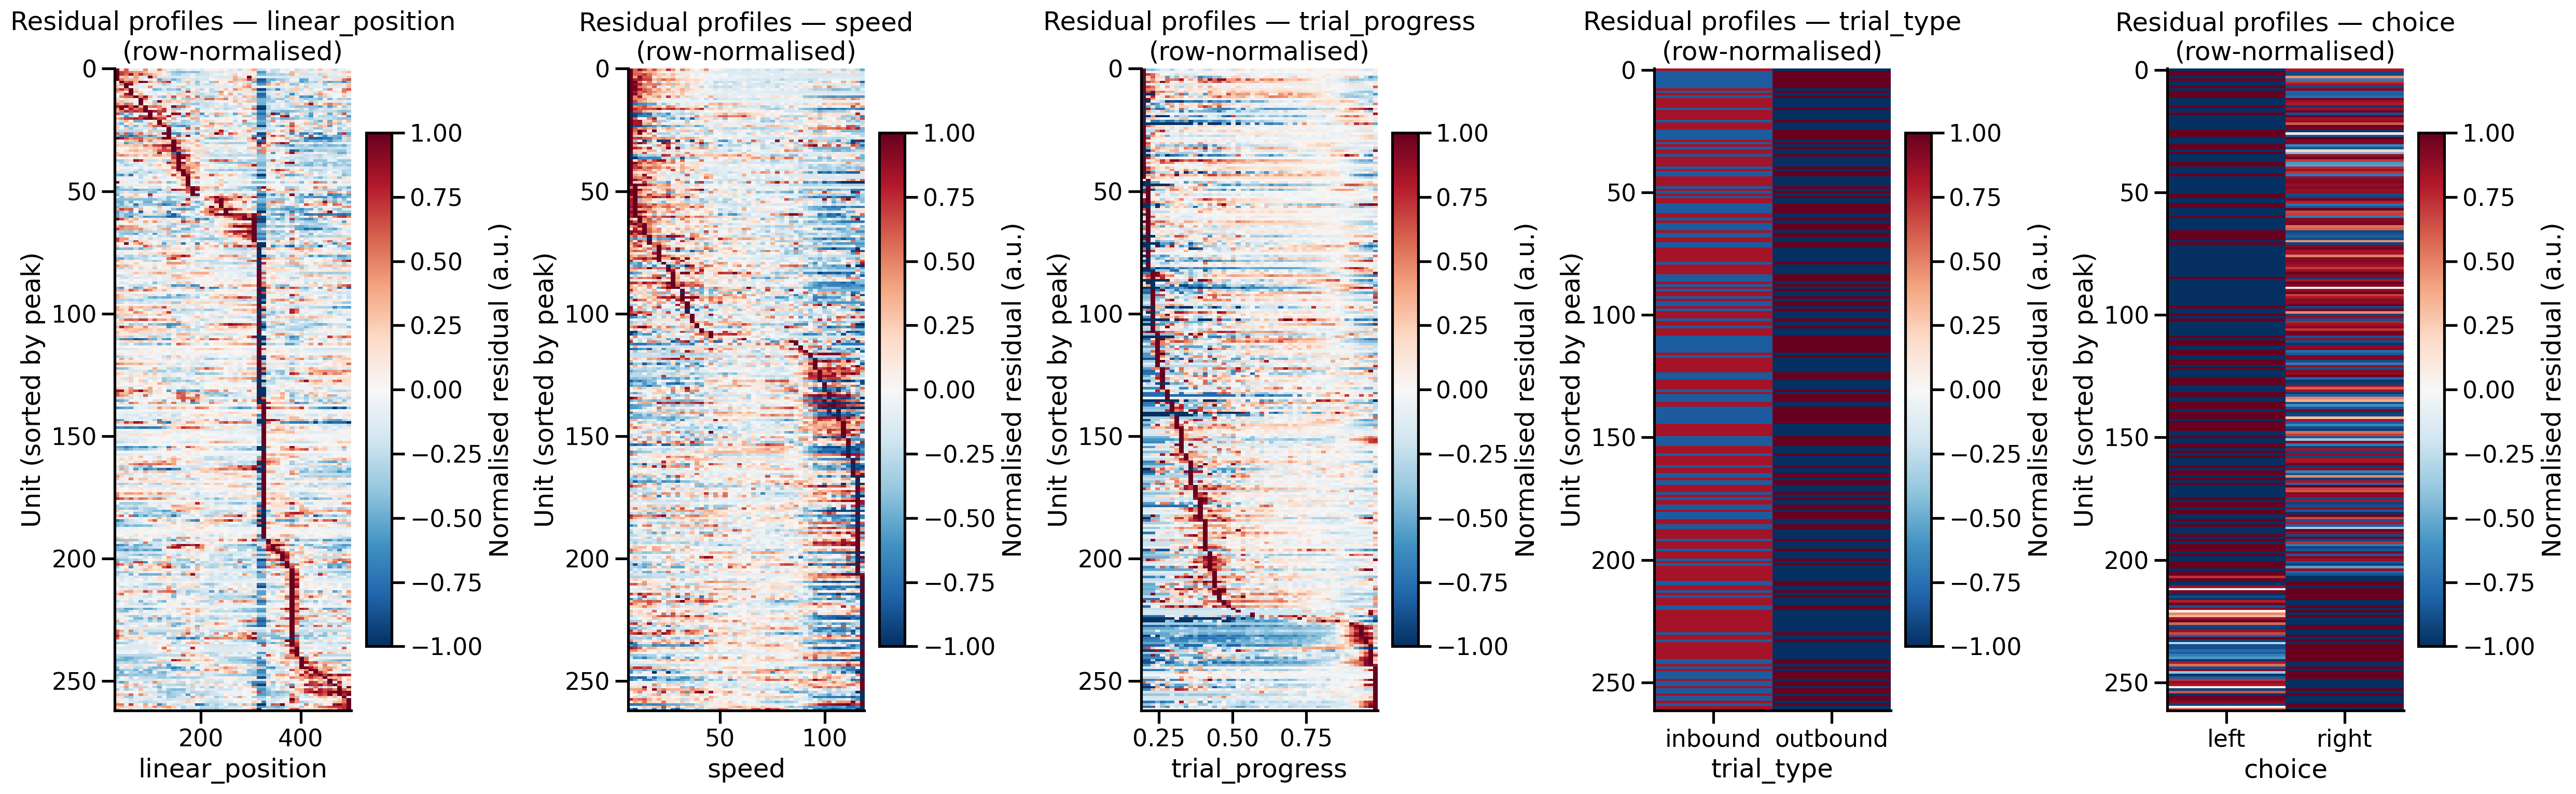

In [16]:
panels = {
    "linear_position": "continuous",
    "speed":           "continuous",
    "trial_progress":  "continuous",
    "trial_type":      "categorical",
    "choice":          "categorical",
}

plot_residual_heterogeneity(prof_null, panels=panels, row_normalise=True)


### Null (outbound only)

#### Fit on one unit

In [17]:
unit_idx = 9

results_constant_out = fit_single_unit(registry["null_outbound"]["formula"],
                                       cov_df_out_common, spike_counts_out_common, unit_idx)
print(results_constant_out.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            spike_count   No. Observations:               195510
Model:                            GLM   Df Residuals:                   195509
Model Family:                 Poisson   Df Model:                            0
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3073.7
Date:                Sat, 21 Mar 2026   Deviance:                       5283.3
Time:                        18:39:55   Pearson chi2:                 1.95e+05
No. Iterations:                     8   Pseudo R-squ. (CS):              0.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -6.1149      0.048   -127.097      0.0

In [ ]:
# Interpret the coefficient
mean_count_per_bin = np.exp(results_constant_out.params["Intercept"])
mean_rate_hz = mean_count_per_bin / BIN_SIZE

print(f"β₀ = {results_constant_out.params['Intercept']:.4f}")
print(f"exp(β₀) = {mean_count_per_bin:.4f} spikes/bin")
print(f"Firing rate = {mean_rate_hz:.2f} Hz")

_out_df = cov_df_out_common.copy()
_out_df["spike_count"] = spike_counts_out_common[unit_idx]
print(f'Observed mean = {_out_df["spike_count"].mean():.4f} spikes/bin')

β₀ = -6.1149
exp(β₀) = 0.0022 spikes/bin
Firing rate = 1.10 Hz
Observed mean = 0.0022 spikes/bin


In [20]:
# Diagnostics — null outbound
plot_diagnostics(
    results        = results_constant_out,
    spike_counts   = spike_counts_out_common[unit_idx],
    cov_df         = cov_df_out_common,
)

In [ ]:
formula = registry["null_outbound"]["formula"]

plot_diagnostics_batch(
    unit_list           = UNIT_LIST,
    formula             = formula,
    cov_df              = cov_df_out_common,
    spike_counts_masked = spike_counts_out_common,
    unit_ids            = unit_ids,
)

#### Fit on all units

In [23]:
null_model_out_all = fit_glm_all_units("spike_count ~ 1", cov_df_out_common, spike_counts_out_common, unit_ids, model_name="null_out", refit = False)

Loading cached fit from /media/labuser/NA_1_2025/spyglass/wilbur/analysis/null_out_model_all.csv


In [24]:
null_model_out_all.head(1)

,unit,aic,llf,deviance,n_params,n_obs,converged,coef,bse,deviance_null,df_model,error,model
0,0,43029.533433157,-21513.766716578,34015.851199324,1.000000000,195510.000000000,True,{'Intercept': -3.769314375497827},{'Intercept': 0.01489058393604296},34015.851199324,0.000000000,NaN,null_out


In [25]:
COVARIATE_COLS     = ["linear_position", "speed", "trial_progress"]
CATEGORICAL_COLS   = ["trial_type", "choice"]

diag_null_out, prof_null_out = load_model_outputs("null_model_out_all")
plot_diagnostics_population(diag_null_out, covariate_cols=COVARIATE_COLS)

/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:1365: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=long_df, x="model", y="ks_D", order=model_order,
/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:1374: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=long_df, x="model", y="drift_auc", order=model_order,
/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:1381: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=long_df, x="model", y="ks_z_autocorr", order=model_order,

In [26]:
plot_residual_profiles(prof_null_out, covariate_cols=COVARIATE_COLS)

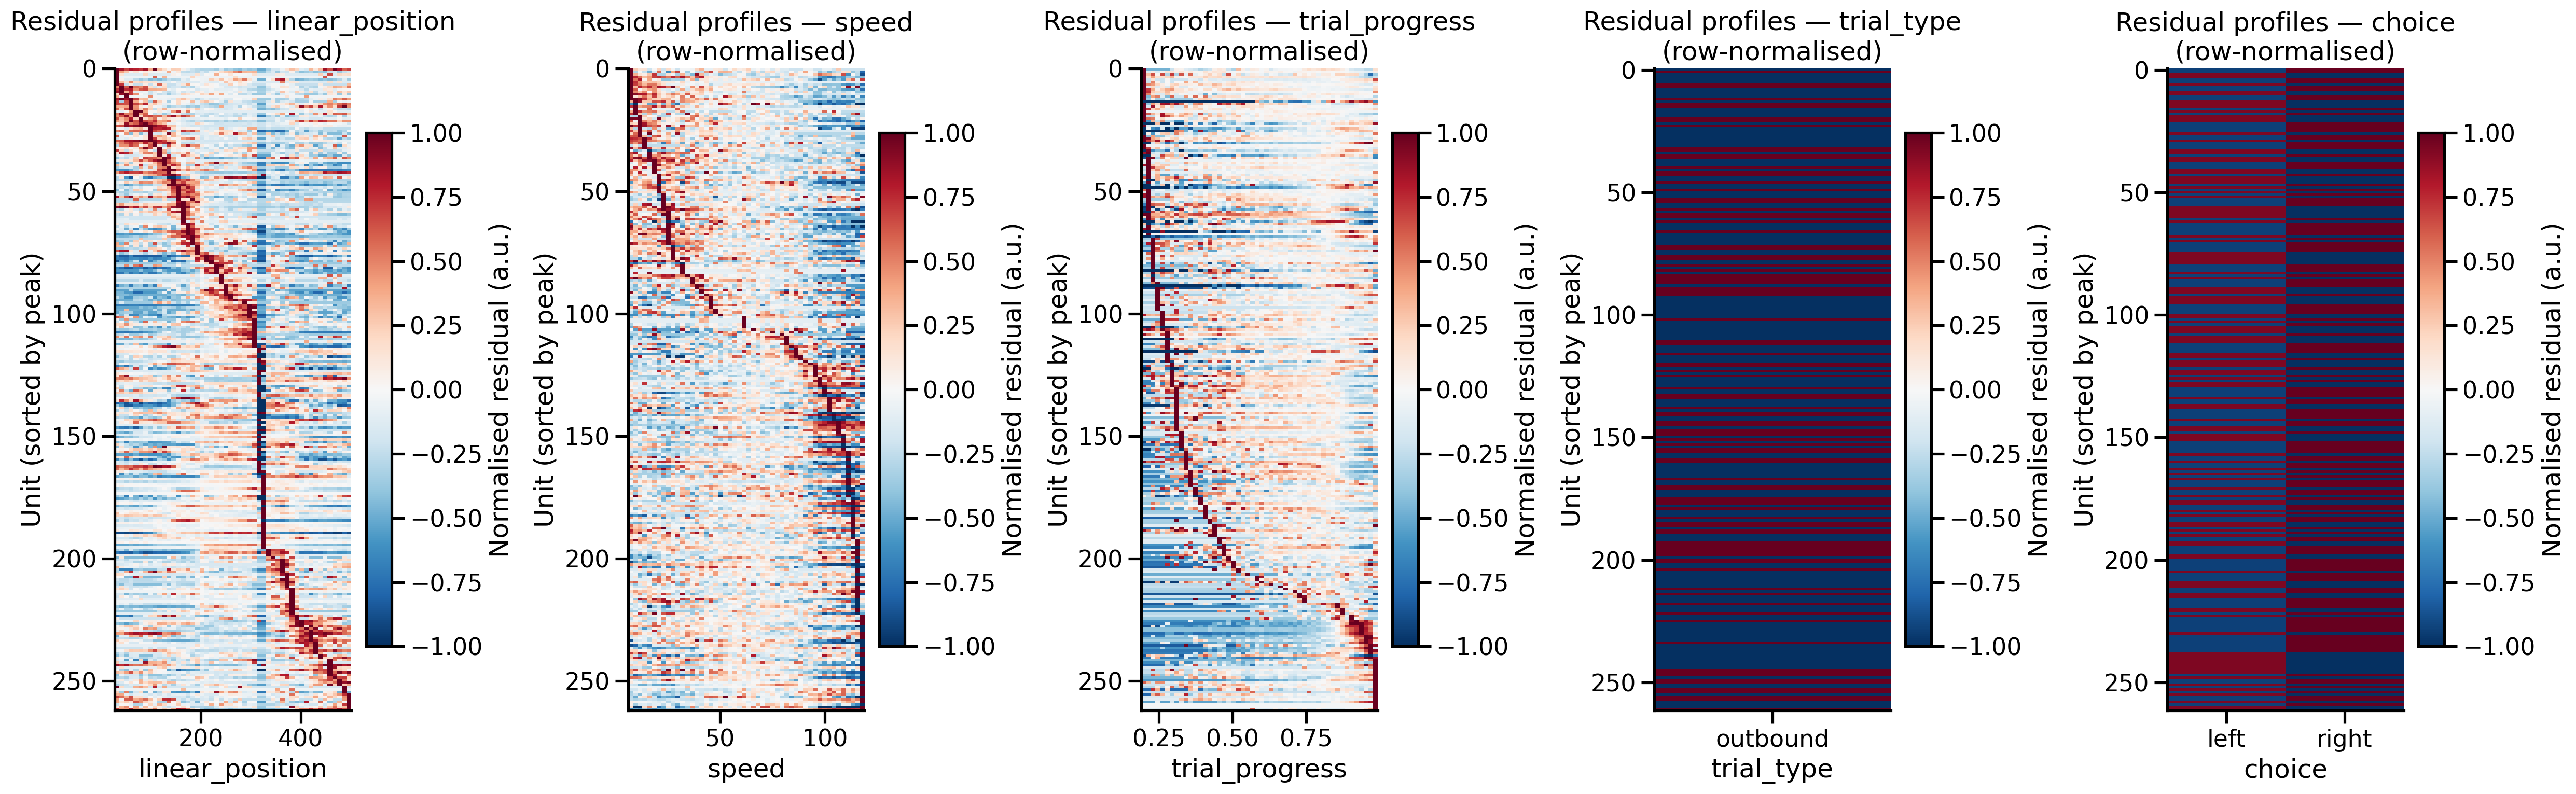

In [27]:
plot_residual_heterogeneity(prof_null_out)

### Trial type

#### Fit on one unit

In [28]:
unit_idx = 9

results_trial_type = fit_single_unit(registry["trial_type"]["formula"],
                                     cov_df_common, spike_counts_common, unit_idx)
print(results_trial_type.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            spike_count   No. Observations:               430792
Model:                            GLM   Df Residuals:                   430790
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -10713.
Date:                Sat, 21 Mar 2026   Deviance:                       18122.
Time:                        18:43:41   Pearson chi2:                 4.29e+05
No. Iterations:                     8   Pseudo R-squ. (CS):          0.0006030
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -5

In [30]:
#interpret coefficients
rate_inbound  = np.exp(results_trial_type.params["Intercept"]) / BIN_SIZE        # Hz
rate_outbound = np.exp(results_trial_type.params["Intercept"] + results_trial_type.params["trial_type[T.outbound]"]) / BIN_SIZE
ratio         = np.exp(results_trial_type.params["trial_type[T.outbound]"])      # outbound/inbound rate ratio

print("inbound rate: ", rate_inbound)
print("outbound rate: ", rate_outbound)
print("outbound/inbound: ", ratio)

inbound rate:  2.5926335206371998
outbound rate:  1.1048028233904446
outbound/inbound:  0.4261315047407525


In [29]:
plot_categorical_comparison(results_trial_type, "trial_type", spk_cov_df_common)


In [31]:
# Diagnostics — trial_type model
plot_diagnostics(
    results        = results_trial_type,
    spike_counts   = spike_counts_common[unit_idx],
    cov_df         = cov_df_common,
)

In [ ]:
formula = registry["trial_type"]["formula"]

plot_diagnostics_batch(
    unit_list           = UNIT_LIST,
    formula             = formula,
    cov_df              = cov_df_common,
    spike_counts_masked = spike_counts_common,
    unit_ids            = unit_ids,
)

#### Fit all units 

In [33]:
trial_type_model_all = fit_glm_all_units("spike_count ~ trial_type", cov_df_common, spike_counts_common, unit_ids, model_name = "trial_type", refit = False)

Loading cached fit from /media/labuser/NA_1_2025/spyglass/wilbur/analysis/trial_type_model_all.csv


In [34]:
trial_type_model_all.head(1)

,unit,aic,llf,deviance,n_params,n_obs,converged,coef,bse,deviance_null,df_model,error,model
0,0,100737.887388474,-50366.943694237,79288.999570058,2.000000000,430792.000000000,True,"{'Intercept': -3.6318901188331854, 'trial_type...","{'Intercept': 0.012672449437512294, 'trial_typ...",79338.721765096,1.000000000,NaN,trial_type


In [35]:
diag_trial_type, prof_trial_type = load_model_outputs("trial_type_model_all")
plot_diagnostics_population(diag_trial_type, covariate_cols=COVARIATE_COLS)

/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:1365: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=long_df, x="model", y="ks_D", order=model_order,
/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:1374: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=long_df, x="model", y="drift_auc", order=model_order,
/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:1381: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=long_df, x="model", y="ks_z_autocorr", order=model_order,

In [36]:
plot_residual_profiles(prof_trial_type, covariate_cols=COVARIATE_COLS)

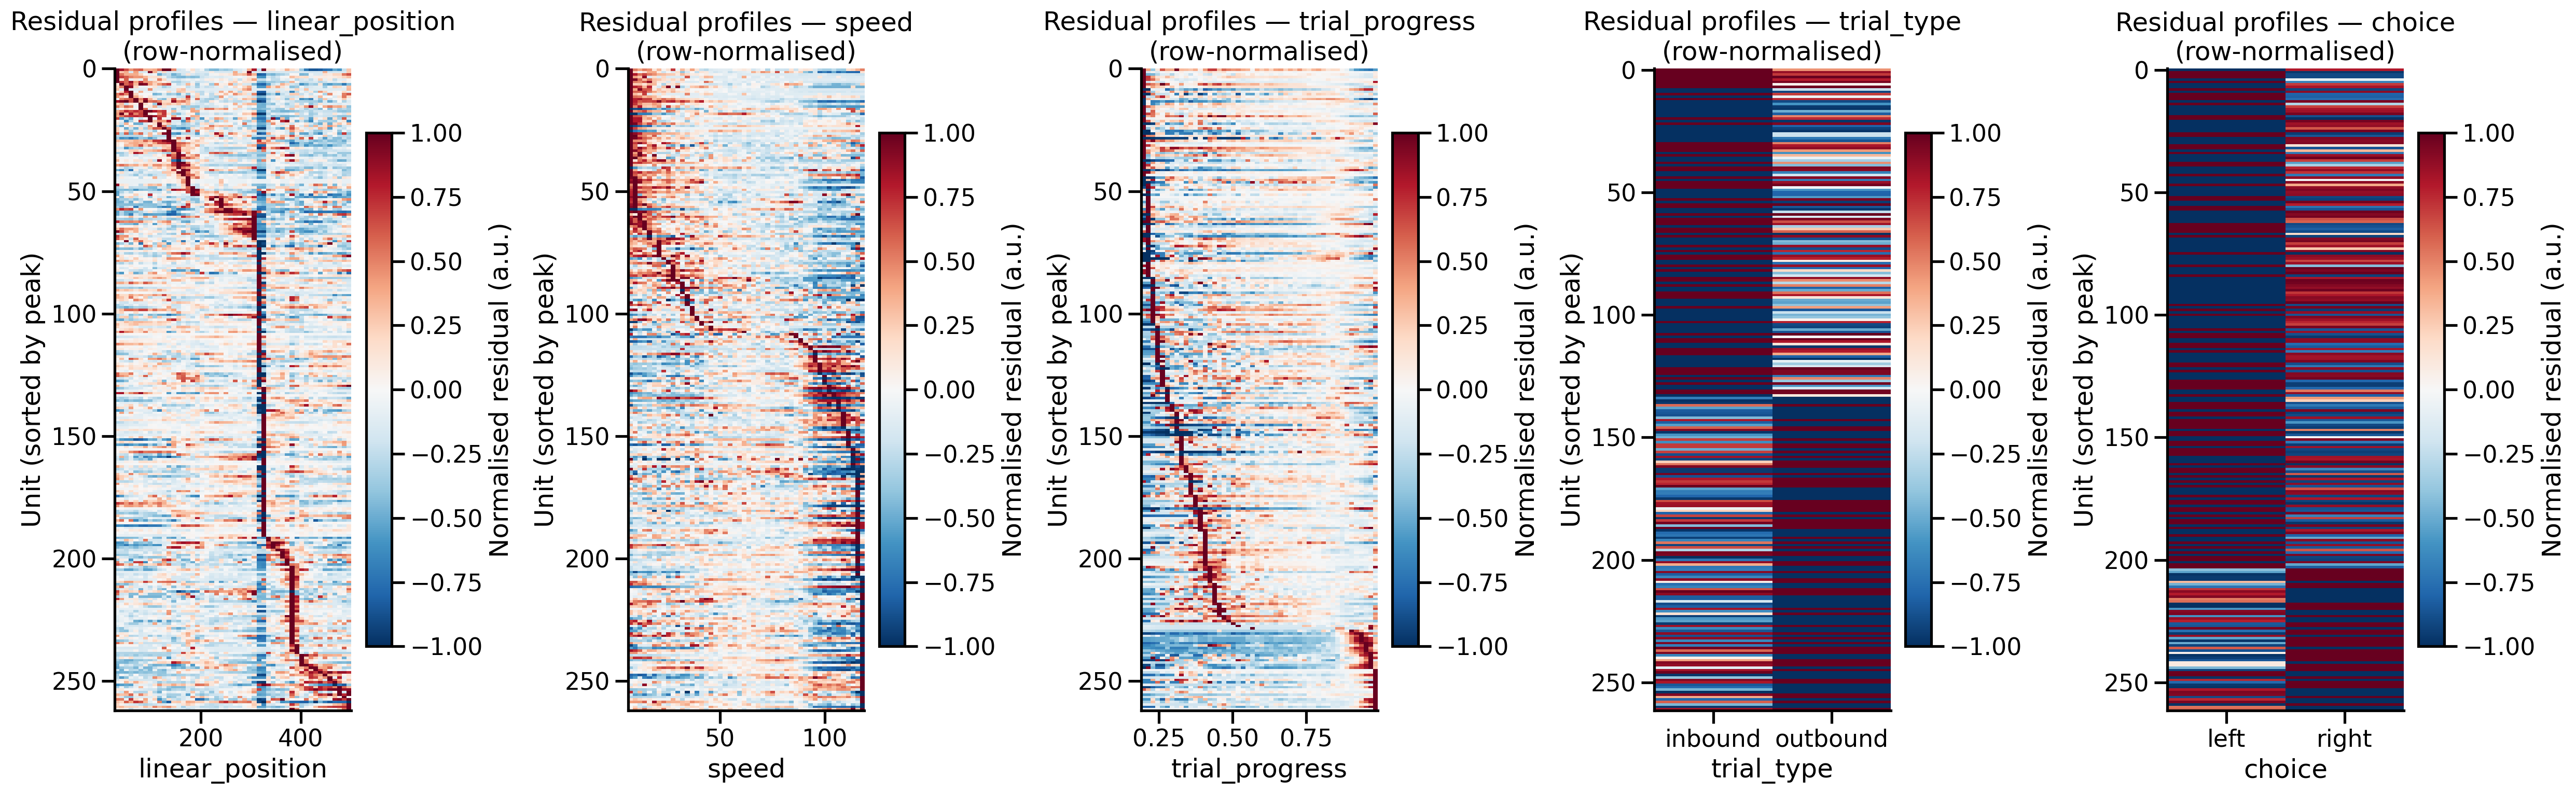

In [37]:
plot_residual_heterogeneity(prof_trial_type)

### Choice

#### Fit on one unit

In [46]:
unit_idx = 9

# Per-unit outbound DataFrame used by downstream viz cells
choice_spk_cov_df = cov_df_out_common.copy()
choice_spk_cov_df["spike_count"] = spike_counts_out_common[unit_idx]

results_choice = fit_single_unit(registry["choice"]["formula"],
                                 cov_df_out_common, spike_counts_out_common, unit_idx)
print(results_choice.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            spike_count   No. Observations:               195510
Model:                            GLM   Df Residuals:                   195508
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3051.0
Date:                Sat, 21 Mar 2026   Deviance:                       5238.0
Time:                        18:46:39   Pearson chi2:                 1.95e+05
No. Iterations:                     8   Pseudo R-squ. (CS):          0.0002317
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -6.4876      0.081    -

In [47]:
#interpret coefficients
rate_left  = np.exp(results_choice.params["Intercept"]) / BIN_SIZE        # Hz
rate_right = np.exp(results_choice.params["Intercept"] + results_choice.params["choice[T.right]"]) / BIN_SIZE
ratio         = np.exp(results_choice.params["choice[T.right]"])      # outbound/inbound rate ratio

print("left rate: ", rate_left)
print("right rate: ", rate_right)
print("right/left: ", ratio)

left rate:  0.7610726181905239
right rate:  1.4734409616635504
right/left:  1.9360057456366078


In [48]:
plot_categorical_comparison(results_choice, "choice", choice_spk_cov_df)


In [49]:
# Diagnostics — choice model
plot_diagnostics(
    results        = results_choice,
    spike_counts   = choice_spk_cov_df["spike_count"].values,
    cov_df         = choice_spk_cov_df,
)

In [50]:
formula = registry["choice"]["formula"]

plot_diagnostics_batch(
    unit_list           = UNIT_LIST,
    formula             = formula,
    cov_df              = cov_df_out_common,
    spike_counts_masked = spike_counts_out_common,
    unit_ids            = unit_ids,
)

#### Fit for all units

In [52]:
choice_model_all = fit_glm_all_units("spike_count ~ choice", cov_df_out_common, spike_counts_out_common, unit_ids, model_name = "choice", refit = False)

Loading cached fit from /media/labuser/NA_1_2025/spyglass/wilbur/analysis/choice_model_all.csv


In [53]:
diag_choice, prof_choice = load_model_outputs("choice_model_all")
plot_diagnostics_population(diag_choice, covariate_cols=COVARIATE_COLS)

/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:1365: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=long_df, x="model", y="ks_D", order=model_order,
/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:1374: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=long_df, x="model", y="drift_auc", order=model_order,
/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:1381: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=long_df, x="model", y="ks_z_autocorr", order=model_order,

In [54]:
plot_residual_profiles(prof_choice, covariate_cols=COVARIATE_COLS)

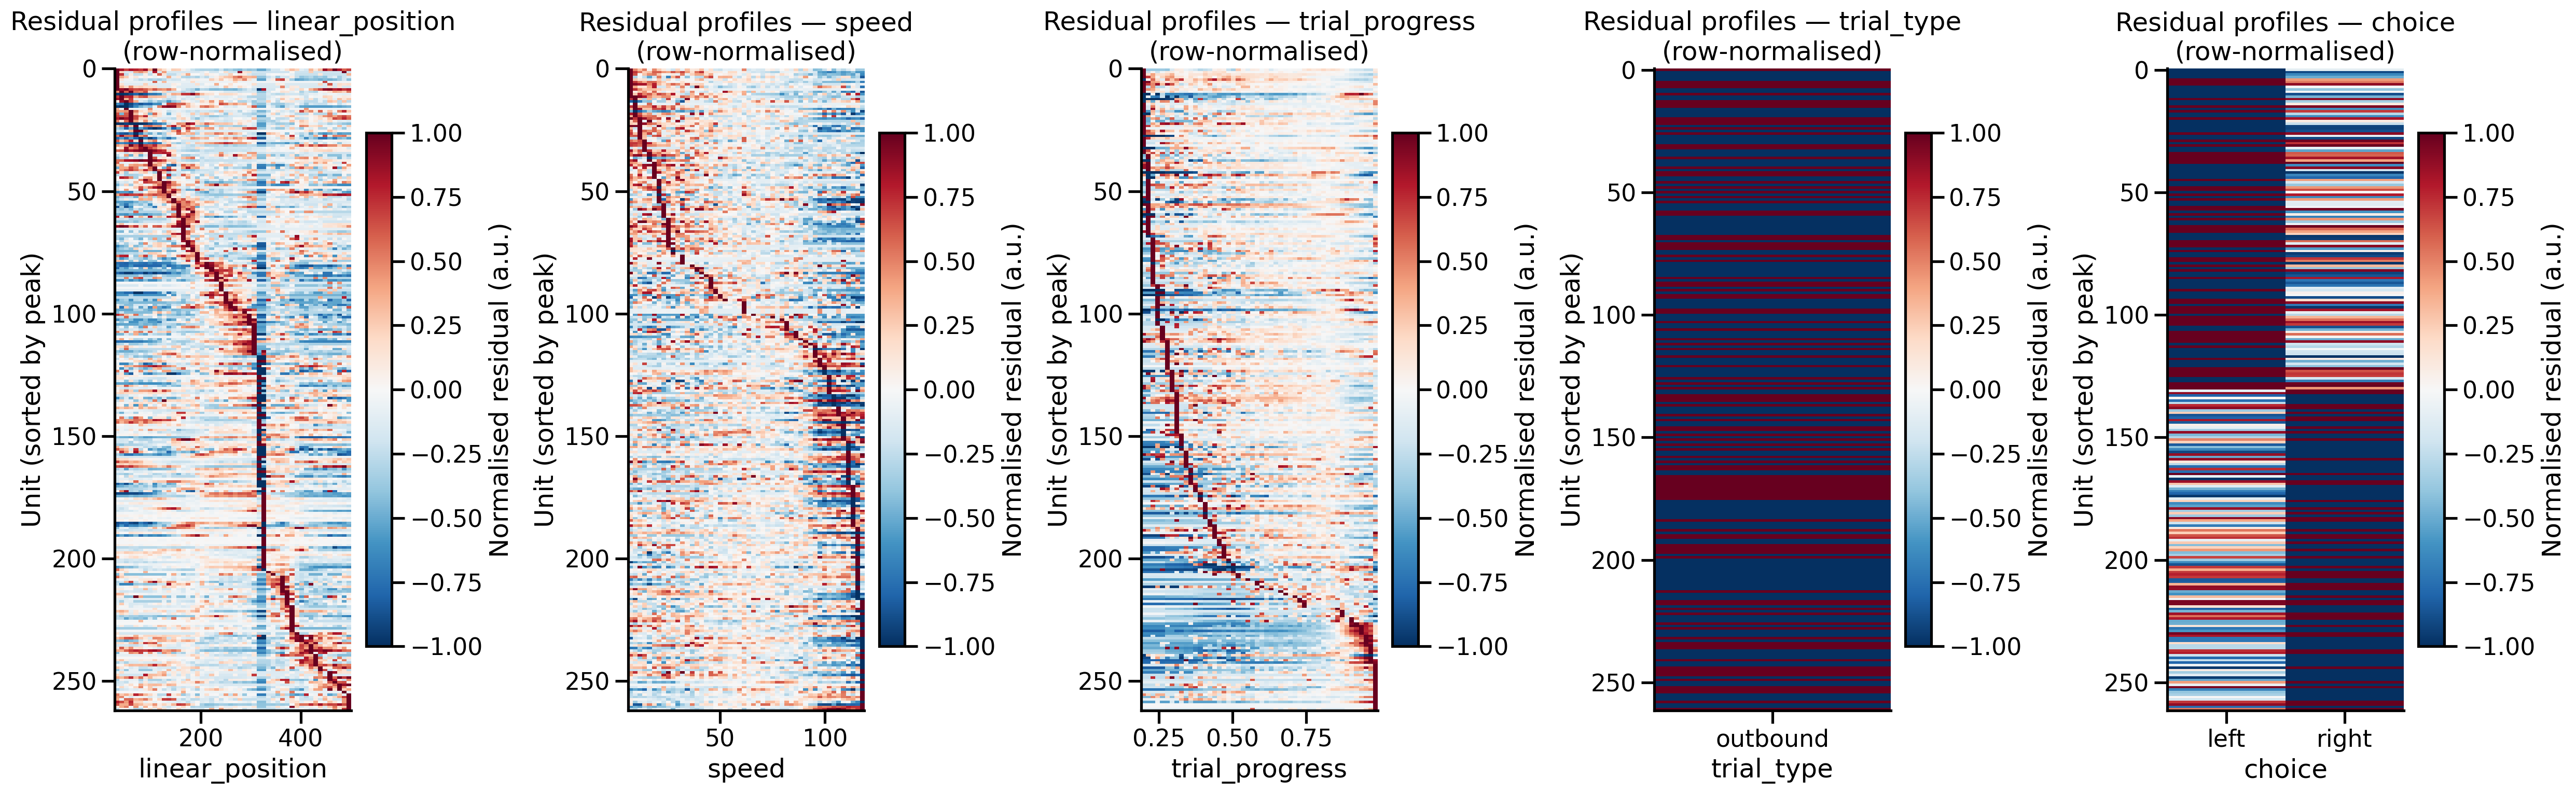

In [55]:
plot_residual_heterogeneity(prof_choice)

### Speed (spline)

#### Fit on one unit


In [56]:
unit_idx = 9

from patsy import bs, cr

results_speed_spline = fit_single_unit(registry["speed_spline"]["formula"],
                                       cov_df_common, spike_counts_common, unit_idx)
print(results_speed_spline.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            spike_count   No. Observations:               430792
Model:                            GLM   Df Residuals:                   430787
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -10532.
Date:                Sat, 21 Mar 2026   Deviance:                       17761.
Time:                        18:47:38   Pearson chi2:                 4.30e+05
No. Iterations:                     8   Pseudo R-squ. (CS):           0.001441
Covariance Type:            nonrobust                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [57]:
plot_tuning_comparison(
    results_speed_spline,
    pd.DataFrame({"speed_scaled": np.linspace(0, 1, 200)}),
    "speed_scaled",
    "speed",
    spk_cov_df_common,
    min_val=speed_min_val,
    max_val=speed_max_val,
    xlabel="Speed (cm/s)",
)


In [59]:
#interpret coefficients
speeds_of_interest = [10, 20, 30, 40, 60]
speeds_scaled = (np.array(speeds_of_interest) - speed_min_val) / (speed_max_val - speed_min_val)
rates = results_speed_spline.predict(pd.DataFrame({"speed_scaled": speeds_scaled})) / BIN_SIZE

print("Spline model — predicted rates:")
for s, r in zip(speeds_of_interest, rates):
    print(f"  speed={s:2f} cm/s : {r:.2f} Hz")

speed_range = np.linspace(speed_min_val, speed_max_val, 500)
speed_range_scaled = (speed_range - speed_min_val) / (speed_max_val - speed_min_val)
pred_curve = results_speed_spline.predict(pd.DataFrame({"speed_scaled": speed_range_scaled})) / BIN_SIZE
peak_speed = speed_range[np.argmax(pred_curve)]
print(f"\nPeak firing at: {peak_speed:.1f} cm/s ({pred_curve.max():.2f} Hz)")
print(f"Rate ratio high/low speed: {pred_curve.max() / pred_curve.min():.2f}x")

Spline model — predicted rates:
  speed=10.000000 cm/s : 2.47 Hz
  speed=20.000000 cm/s : 1.35 Hz
  speed=30.000000 cm/s : 0.93 Hz
  speed=40.000000 cm/s : 0.80 Hz
  speed=60.000000 cm/s : 0.98 Hz

Peak firing at: 119.5 cm/s (5.84 Hz)
Rate ratio high/low speed: 7.39x


In [64]:
# Diagnostics : speed spline
plot_diagnostics(
    results        = results_speed_spline,
    spike_counts   = spike_counts_common[unit_idx],
    cov_df         = cov_df_common,
)

In [66]:
formula = registry["speed_spline"]["formula"]

plot_diagnostics_batch(
    unit_list           = UNIT_LIST,
    formula             = formula,
    cov_df              = cov_df_common,
    spike_counts_masked = spike_counts_common,
    unit_ids            = unit_ids,
)

#### Fit on all units

In [67]:
speed_spline_model_all = fit_glm_all_units(registry["speed_spline"]["formula"],
                                            cov_df_common, spike_counts_common, unit_ids,
                                            model_name = "speed_spline",
                                            refit = False)

Loading cached fit from /media/labuser/NA_1_2025/spyglass/wilbur/analysis/speed_spline_model_all.csv


In [68]:
diag_speed, prof_speed = load_model_outputs("speed_spline_model_all")
plot_diagnostics_population(diag_speed, covariate_cols=COVARIATE_COLS)

/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:1365: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=long_df, x="model", y="ks_D", order=model_order,
/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:1374: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=long_df, x="model", y="drift_auc", order=model_order,
/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:1381: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=long_df, x="model", y="ks_z_autocorr", order=model_order,

In [69]:
plot_residual_profiles(prof_speed, covariate_cols=COVARIATE_COLS)

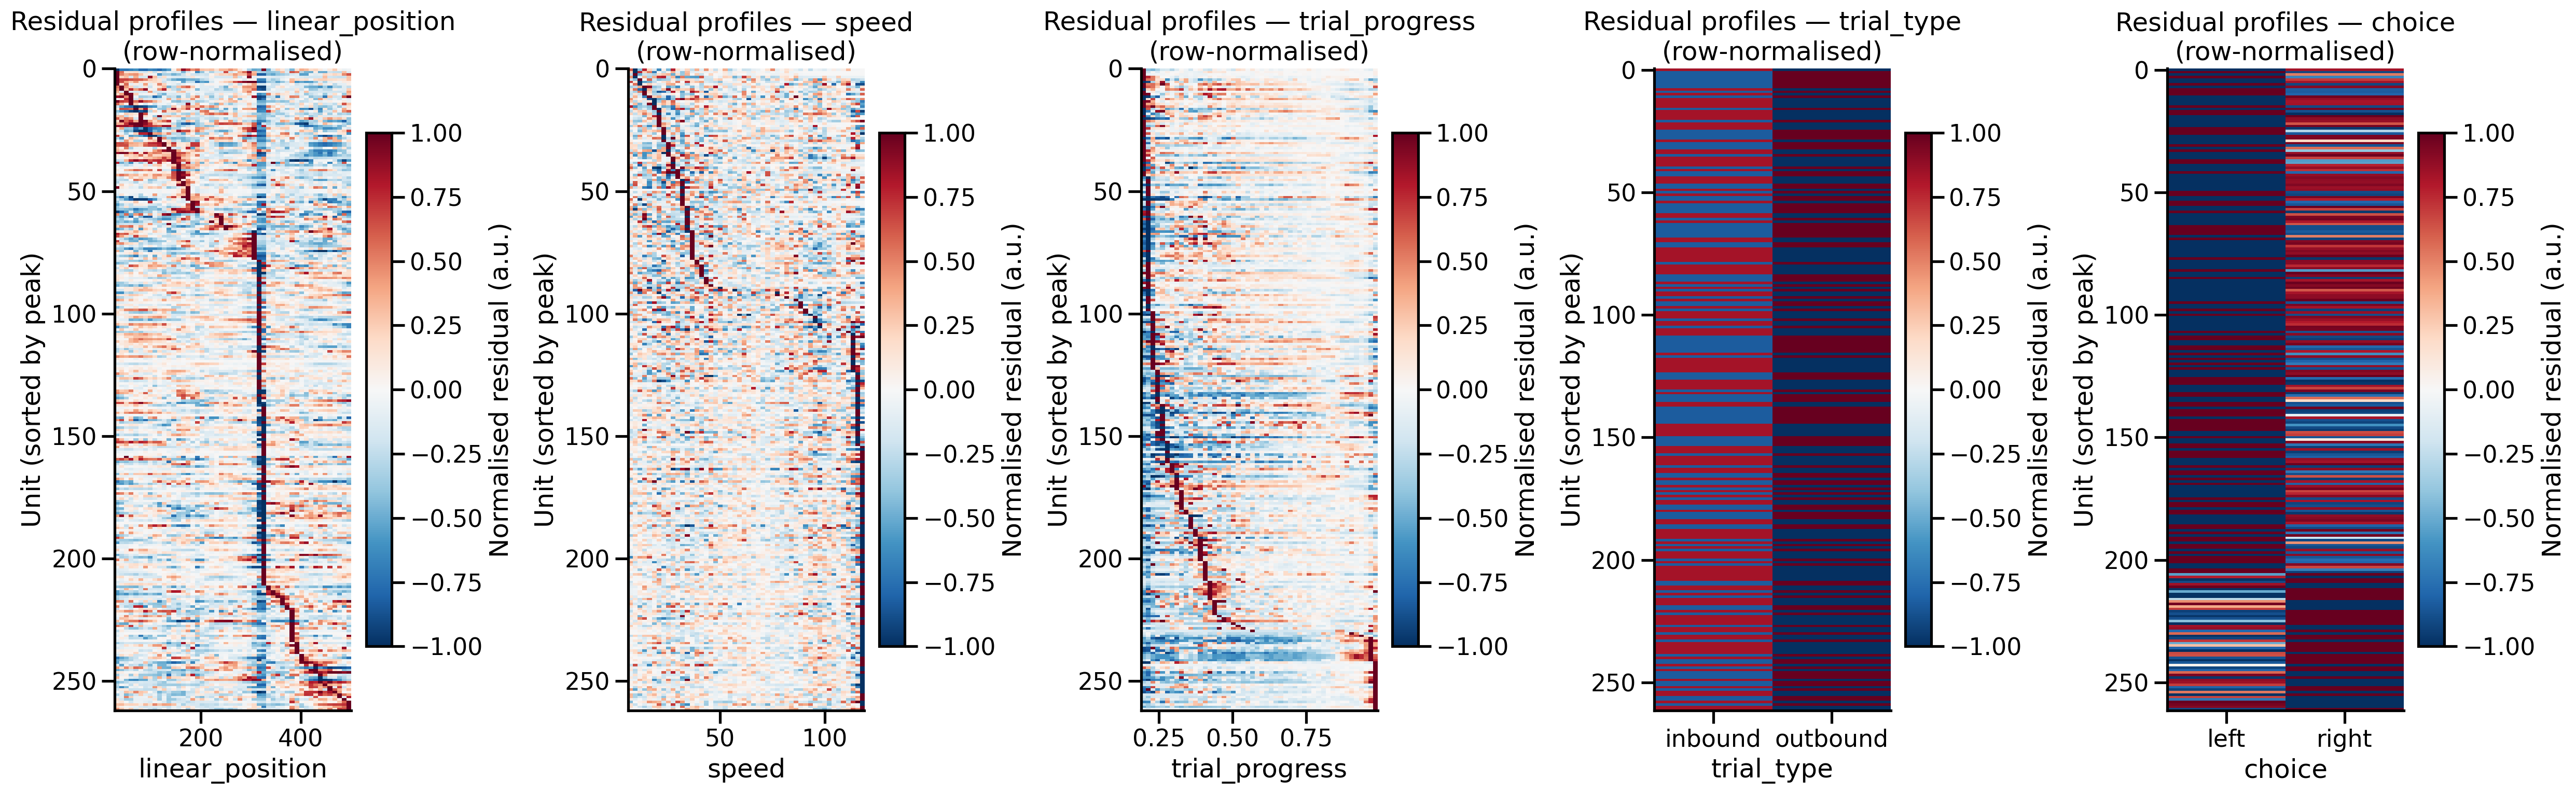

In [70]:
plot_residual_heterogeneity(prof_speed)

### Linear position (spline)

#### Fit on one unit

In [71]:
unit_idx = 9

results_pos_spline = fit_single_unit(registry["pos_spline"]["formula"],
                                     cov_df_common, spike_counts_common, unit_idx)
print(results_pos_spline.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            spike_count   No. Observations:               430792
Model:                            GLM   Df Residuals:                   430783
Model Family:                 Poisson   Df Model:                            8
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -10459.
Date:                Sat, 21 Mar 2026   Deviance:                       17614.
Time:                        18:49:28   Pearson chi2:                 4.30e+05
No. Iterations:                     8   Pseudo R-squ. (CS):           0.001782
Covariance Type:            nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [73]:
_pos_run_cmp = trialized_position[trialized_position["zone"] == "run"][
    ["linear_position", "projected_x_position", "projected_y_position"]
].dropna().iloc[::5].copy()

plot_tuning_comparison(
    results_pos_spline,
    pd.DataFrame({"pos_scaled": np.linspace(0, 1, 200)}),
    "pos_scaled",
    "linear_position",
    spk_cov_df_common,
    min_val=pos_min_val,
    max_val=pos_max_val,
    xlabel="Position (cm)",
)
plot_wtrack_comparison(unit_idx, spk_cov_df_common,
                       results=results_pos_spline, pos_run=_pos_run_cmp)

In [74]:
pos_range = np.linspace(pos_min_val, pos_max_val, 500)
pos_range_scaled = (pos_range - pos_min_val) / (pos_max_val - pos_min_val)  # changed
pred_rate = results_pos_spline.predict(pd.DataFrame({"pos_scaled": pos_range_scaled})) / BIN_SIZE  # changed

peak_pos  = pos_range[np.argmax(pred_rate)]
peak_rate = pred_rate.max()
print(f"Peak firing position: {peak_pos:.1f} cm, rate: {peak_rate:.2f} Hz")

Peak firing position: 269.1 cm, rate: 5.56 Hz


In [75]:
# Diagnostics — position spline
plot_diagnostics(
    results        = results_pos_spline,
    spike_counts   = spike_counts_common[unit_idx],
    cov_df         = cov_df_common,
)

In [76]:
formula = registry["pos_spline"]["formula"]

plot_diagnostics_batch(
    unit_list           = UNIT_LIST,
    formula             = formula,
    cov_df              = cov_df_common,
    spike_counts_masked = spike_counts_common,
    unit_ids            = unit_ids,
)

#### Fit on all units

In [77]:
pos_spline_model_all = fit_glm_all_units("spike_count ~ bs(pos_scaled, df=8)",
                                          cov_df_common, spike_counts_common, unit_ids,
                                          model_name="pos_spline",
                                          refit = False)

Loading cached fit from /media/labuser/NA_1_2025/spyglass/wilbur/analysis/pos_spline_model_all.csv


In [78]:
pos_spline_model_all.head(1)

,unit,aic,llf,deviance,n_params,n_obs,converged,coef,bse,deviance_null,df_model,error,model
0,0,100018.574871328,-50000.287435664,78555.687052912,9.000000000,430792.000000000,True,"{'Intercept': -3.1763134432068973, 'bs(pos_sca...","{'Intercept': 0.06747874928540872, 'bs(pos_sca...",79338.721765096,8.000000000,NaN,pos_spline


In [79]:
diag_pos, prof_pos = load_model_outputs("pos_spline_model_all")
plot_diagnostics_population(diag_pos, covariate_cols=COVARIATE_COLS)

/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:1365: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=long_df, x="model", y="ks_D", order=model_order,
/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:1374: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=long_df, x="model", y="drift_auc", order=model_order,
/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:1381: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=long_df, x="model", y="ks_z_autocorr", order=model_order,

In [80]:
plot_residual_profiles(prof_pos, covariate_cols=COVARIATE_COLS)

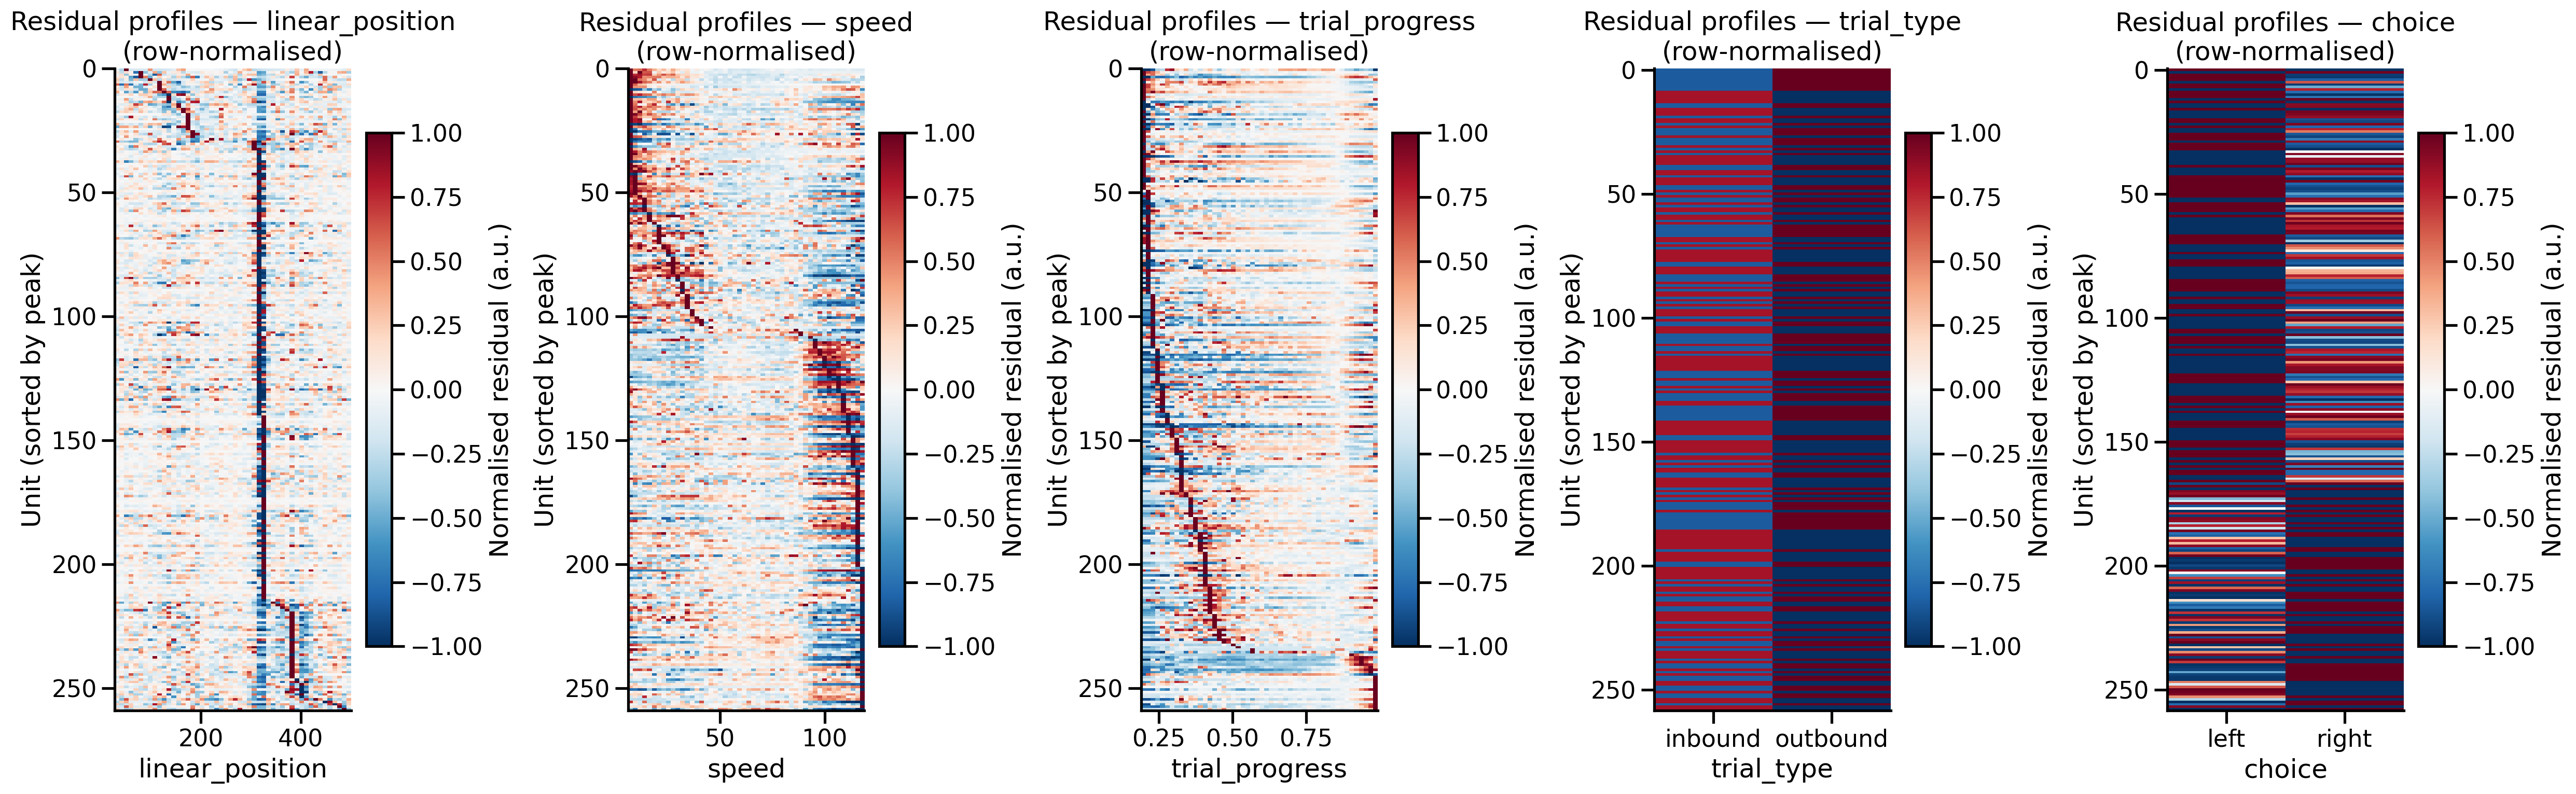

In [81]:
plot_residual_heterogeneity(prof_pos)

### Trial progress (spline)

#### Fit on one unit

In [86]:
unit_idx = 9

results_tp_spline = fit_single_unit(registry["trial_progress_spline"]["formula"],
                                    cov_df_common, spike_counts_common, unit_idx)
print(results_tp_spline.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            spike_count   No. Observations:               430792
Model:                            GLM   Df Residuals:                   430785
Model Family:                 Poisson   Df Model:                            6
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -10294.
Date:                Sat, 21 Mar 2026   Deviance:                       17284.
Time:                        18:51:41   Pearson chi2:                 4.34e+05
No. Iterations:                     9   Pseudo R-squ. (CS):           0.002546
Covariance Type:            nonrobust                                         
                                                        coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------

In [87]:
plot_tuning_comparison(
    results_tp_spline,
    pd.DataFrame({"trial_progress": np.linspace(0, 1, 200)}),
    "trial_progress",
    "trial_progress",
    spk_cov_df_common,
    xlabel="Trial progress",
)


In [89]:
# Diagnostics — trial progress spline
plot_diagnostics(
    results        = results_tp_spline,
    spike_counts   = spike_counts_common[unit_idx],
    cov_df         = cov_df_common,
)

In [90]:
formula = registry["trial_progress_spline"]["formula"]

plot_diagnostics_batch(
    unit_list           = UNIT_LIST,
    formula             = formula,
    cov_df              = cov_df_common,
    spike_counts_masked = spike_counts_common,
    unit_ids            = unit_ids,
)

#### Fit on all units

In [94]:
trial_progress_spline_model_all = fit_glm_all_units(f"spike_count ~ cr(trial_progress, df=6, constraints='center')",
                                                  cov_df_common, spike_counts_common, unit_ids,
                                                  model_name="trial_progress",
                                                  refit = False)

Loading cached fit from /media/labuser/NA_1_2025/spyglass/wilbur/analysis/trial_progress_model_all.csv


In [95]:
trial_progress_spline_model_all.head(1)

,unit,aic,llf,deviance,n_params,n_obs,converged,coef,bse,deviance_null,df_model,error,model
0,0,99380.563188789,-49683.281594395,77921.675370373,7.000000000,430792.000000000,True,"{'Intercept': -3.758817804947291, ""cr(trial_pr...","{'Intercept': 0.01030771117634762, ""cr(trial_p...",79338.721765096,6.000000000,NaN,trial_progress


In [96]:
diag_tp, prof_tp = load_model_outputs("trial_progress_spline_model_all")
plot_diagnostics_population(diag_tp, covariate_cols=COVARIATE_COLS)

/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:1365: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=long_df, x="model", y="ks_D", order=model_order,
/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:1374: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=long_df, x="model", y="drift_auc", order=model_order,
/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:1381: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=long_df, x="model", y="ks_z_autocorr", order=model_order,

In [97]:
plot_residual_profiles(prof_tp, covariate_cols=COVARIATE_COLS)

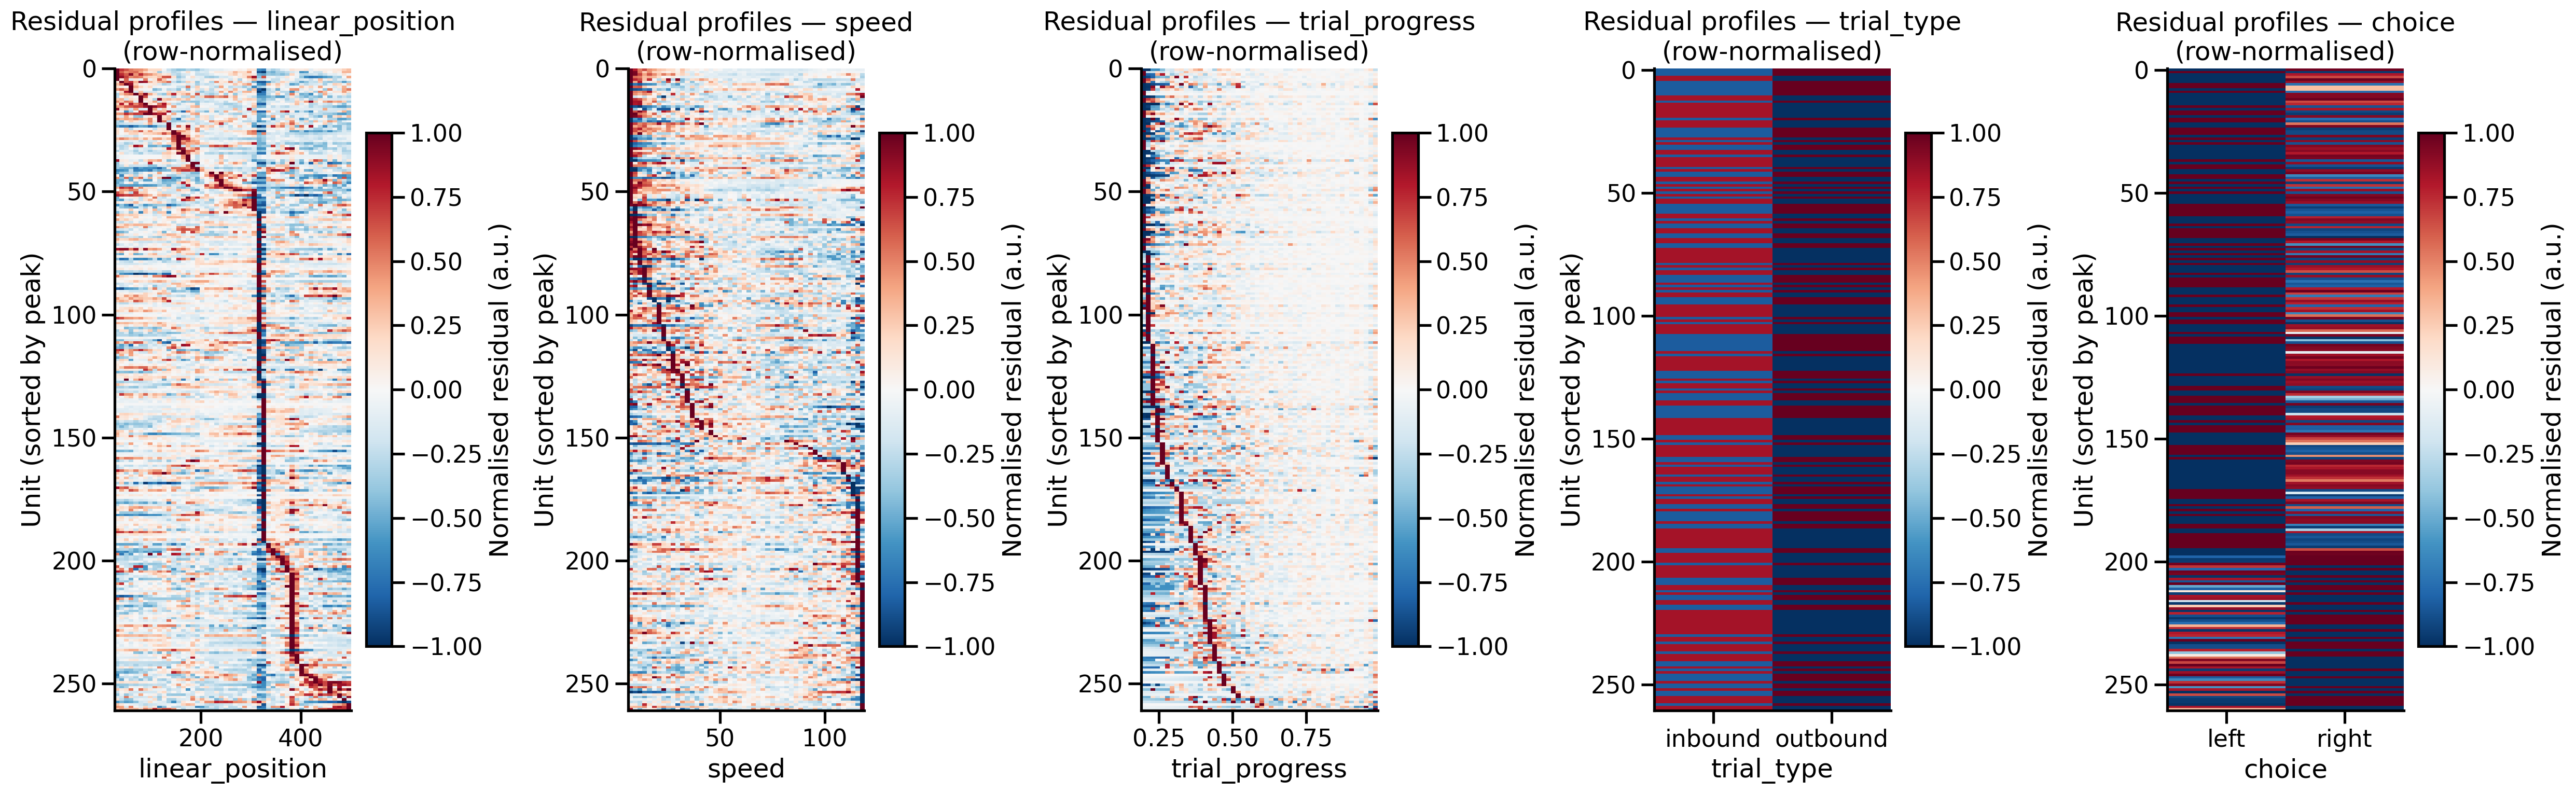

In [98]:
plot_residual_heterogeneity(prof_tp)

## Combined models

### Full model (trial type, position , speed)

#### Fit on one unit

In [15]:
full_model_formula = registry["full_model"]["formula"] + ' + hist_0_2ms + hist_2_10ms + hist_10_50ms + hist_50_200ms'

In [16]:
full_model_formula

'spike_count ~ trial_type + bs(pos_scaled, df=8) + bs(speed_scaled, df=4) + hist_0_2ms + hist_2_10ms + hist_10_50ms + hist_50_200ms'

In [17]:
unit_idx = 9
results_full_pos = fit_single_unit(full_model_formula,
                                   cov_df_common, 
                                   spike_counts_common, 
                                   unit_idx,
                                   per_unit_transform=add_spike_history)
print(results_full_pos.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            spike_count   No. Observations:               427951
Model:                            GLM   Df Residuals:                   427933
Model Family:                 Poisson   Df Model:                           17
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -9637.2
Date:                Wed, 25 Mar 2026   Deviance:                       16006.
Time:                        11:56:40   Pearson chi2:                 4.13e+05
No. Iterations:                    23   Pseudo R-squ. (CS):           0.005104
Covariance Type:            nonrobust                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [19]:
# Diagnostics — full model
plot_diagnostics(
    results        = results_full_pos,
    spike_counts   = spike_counts_common[unit_idx],
    cov_df         = cov_df_common,
)

In [ ]:
plot_diagnostics_batch(
    unit_list           = UNIT_LIST,
    formula             = full_model_formula,
    cov_df              = cov_df_common,
    spike_counts_masked = spike_counts_common,
    unit_ids            = unit_ids,
)

#### Fit on all units

In [104]:
full_model_all = fit_glm_all_units(full_model_formula, cov_df_common, spike_counts_common, unit_ids, model_name="full_model", refit = False)

Loading cached fit from /media/labuser/NA_1_2025/spyglass/wilbur/analysis/full_model_all.csv


In [106]:
full_model_all.head(1)

,unit,aic,llf,deviance,n_params,n_obs,converged,coef,bse,deviance_null,df_model,error,model
0,0,98733.681091744,-49352.840545872,77260.793273327,14.000000000,430792.000000000,True,"{'Intercept': -2.7526942440885533, 'trial_type...","{'Intercept': 0.07883220244871303, 'trial_type...",79338.721765096,13.000000000,NaN,full_model


In [107]:
diag_full, prof_full = load_model_outputs("full_model_all")
plot_diagnostics_population(diag_full, covariate_cols=COVARIATE_COLS)

/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:1365: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=long_df, x="model", y="ks_D", order=model_order,
/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:1374: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=long_df, x="model", y="drift_auc", order=model_order,
/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:1381: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=long_df, x="model", y="ks_z_autocorr", order=model_order,

In [108]:
plot_residual_profiles(prof_full, covariate_cols=COVARIATE_COLS)

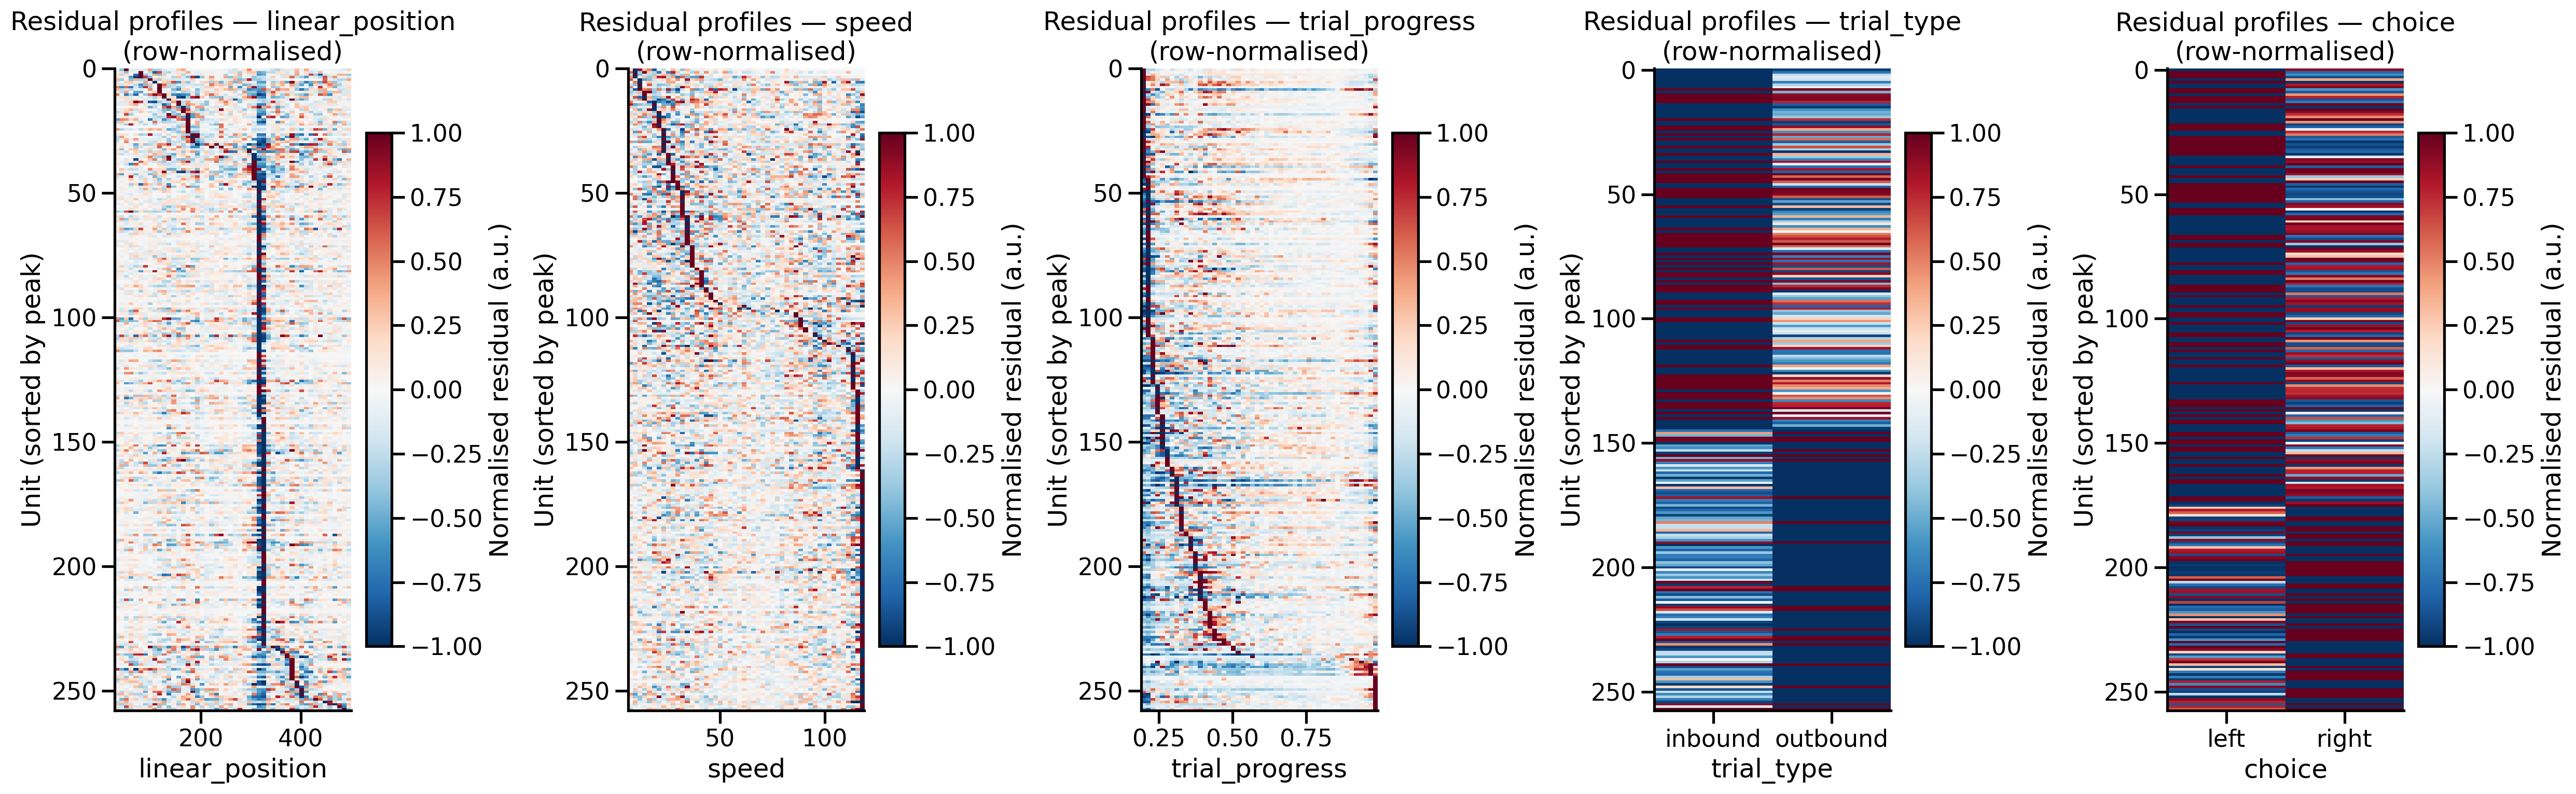

In [109]:
plot_residual_heterogeneity(prof_full, row_normalise=True)

In [ ]:
plot_model_improvement(
    {"null_model": diag_full_null, "full_model": diag_full},
    reference="null_model",
    scalars=["drift_auc"],
) #improvement over the null model in delta-aic

/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:1635: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=sub, x="model", y="delta", order=target_labels,


In [115]:
#plot change in residuals
covariate_cols = [k.replace("_profiles", "") for k in prof_null if k.endswith("_profiles")]
n = len(covariate_cols)
fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4.5), constrained_layout=True)
axes = np.atleast_1d(axes)

ids_null = np.array(prof_null["unit_ids"])
ids_full = np.array(prof_full["unit_ids"])
shared, idx_null, idx_full = np.intersect1d(ids_null, ids_full, return_indices=True)

for ax, col in zip(axes, covariate_cols):
    mat_null = np.array(prof_null[f"{col}_profiles"])[idx_null]
    mat_full = np.array(prof_full[f"{col}_profiles"])[idx_full]
    rms_null = np.sqrt(np.nanmean(mat_null ** 2, axis=1))
    rms_full = np.sqrt(np.nanmean(mat_full ** 2, axis=1))

    lim = max(np.nanmax(rms_null), np.nanmax(rms_full)) * 1.1
    ax.scatter(rms_null, rms_full, s=12, alpha=0.5, color="steelblue")
    ax.plot([0, lim], [0, lim], color="red", lw=1, ls="--", label="no change")
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel("null model RMS (spikes/bin)")
    ax.set_ylabel("full model RMS (spikes/bin)")
    ax.set_title(col)
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

fig.suptitle(f"Per-neuron RMS of binned residual profiles: null vs full model  (n={len(shared)} units)", fontsize=12)


Text(0.5, 0.98, 'Per-neuron RMS of binned residual profiles: null vs full model  (n=258 units)')

In [116]:
# Marginal place tuning on W-track 
pos_run = trialized_position[trialized_position["zone"] == "run"][
    ["linear_position", "projected_x_position", "projected_y_position"]
].dropna().iloc[::5].copy()

plot_marginal_tuning(
    results_full_pos, "pos_scaled", "pos_scaled", "linear_position",
    spk_cov_df_common, unit_idx=unit_idx,
    min_val=pos_min_val, max_val=pos_max_val,
    wtrack=True, pos_run=pos_run, title="full model",
)

In [117]:
# Marginal speed tuning from full model 
plot_marginal_tuning(
    results_full_pos, "speed_scaled", "speed_scaled", "speed",
    spk_cov_df_common, unit_idx=unit_idx,
    min_val=speed_min_val, max_val=speed_max_val,
    xlabel="Speed (cm/s)", title=f"Unit {unit_idx}, speed tuning",
)

In [118]:
#  Marginal trial type tuning from full model 
plot_marginal_tuning(
    results_full_pos, "trial_type", "trial_type", "trial_type",
    spk_cov_df_common, unit_idx=unit_idx,
    categorical=True, xlabel="Trial type",
    title=f"Unit {unit_idx}, trial type tuning",
)

### Temporal full model (trial type, progress, speed)

Replaces position with trial_progress — same structure as full model but asks whether mPFC tracks *when within a trial* rather than *where on the track*. Compare AIC directly to `full_model` (same dataset, same n_obs).

#### Fit on one unit

In [ ]:
temporal_model_formula = registry["temporal_model"]["formula"]
unit_idx = 9
results_temporal = fit_single_unit(temporal_model_formula,
                                   cov_df_common, spike_counts_common, unit_idx)
print(results_temporal.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            spike_count   No. Observations:               430792
Model:                            GLM   Df Residuals:                   430780
Model Family:                 Poisson   Df Model:                           11
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -10117.
Date:                Sat, 21 Mar 2026   Deviance:                       16929.
Time:                        19:02:59   Pearson chi2:                 4.61e+05
No. Iterations:                     9   Pseudo R-squ. (CS):           0.003367
Covariance Type:            nonrobust                                         
                                                        coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------

In [120]:
# Diagnostics — temporal model
plot_diagnostics(
    results        = results_temporal,
    spike_counts   = spike_counts_common[unit_idx],
    cov_df         = cov_df_common,)

In [122]:
plot_diagnostics_batch(
    unit_list           = UNIT_LIST,
    formula             = temporal_model_formula,
    cov_df              = cov_df_common,
    spike_counts_masked = spike_counts_common,
    unit_ids            = unit_ids,
)

#### Fit on all units

In [124]:
temporal_model_all = fit_glm_all_units(temporal_model_formula, cov_df_common, spike_counts_common, unit_ids, model_name="temporal_model_all", refit = False)

Loading cached fit from /media/labuser/NA_1_2025/spyglass/wilbur/analysis/temporal_model_all_model_all.csv


In [125]:
diag_temporal, prof_temporal = load_model_outputs("temporal_model_all")
plot_diagnostics_population(diag_temporal, covariate_cols=COVARIATE_COLS)

/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:1365: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=long_df, x="model", y="ks_D", order=model_order,
/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:1374: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=long_df, x="model", y="drift_auc", order=model_order,
/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:1381: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=long_df, x="model", y="ks_z_autocorr", order=model_order,

In [126]:
plot_residual_profiles(prof_temporal, covariate_cols=COVARIATE_COLS)

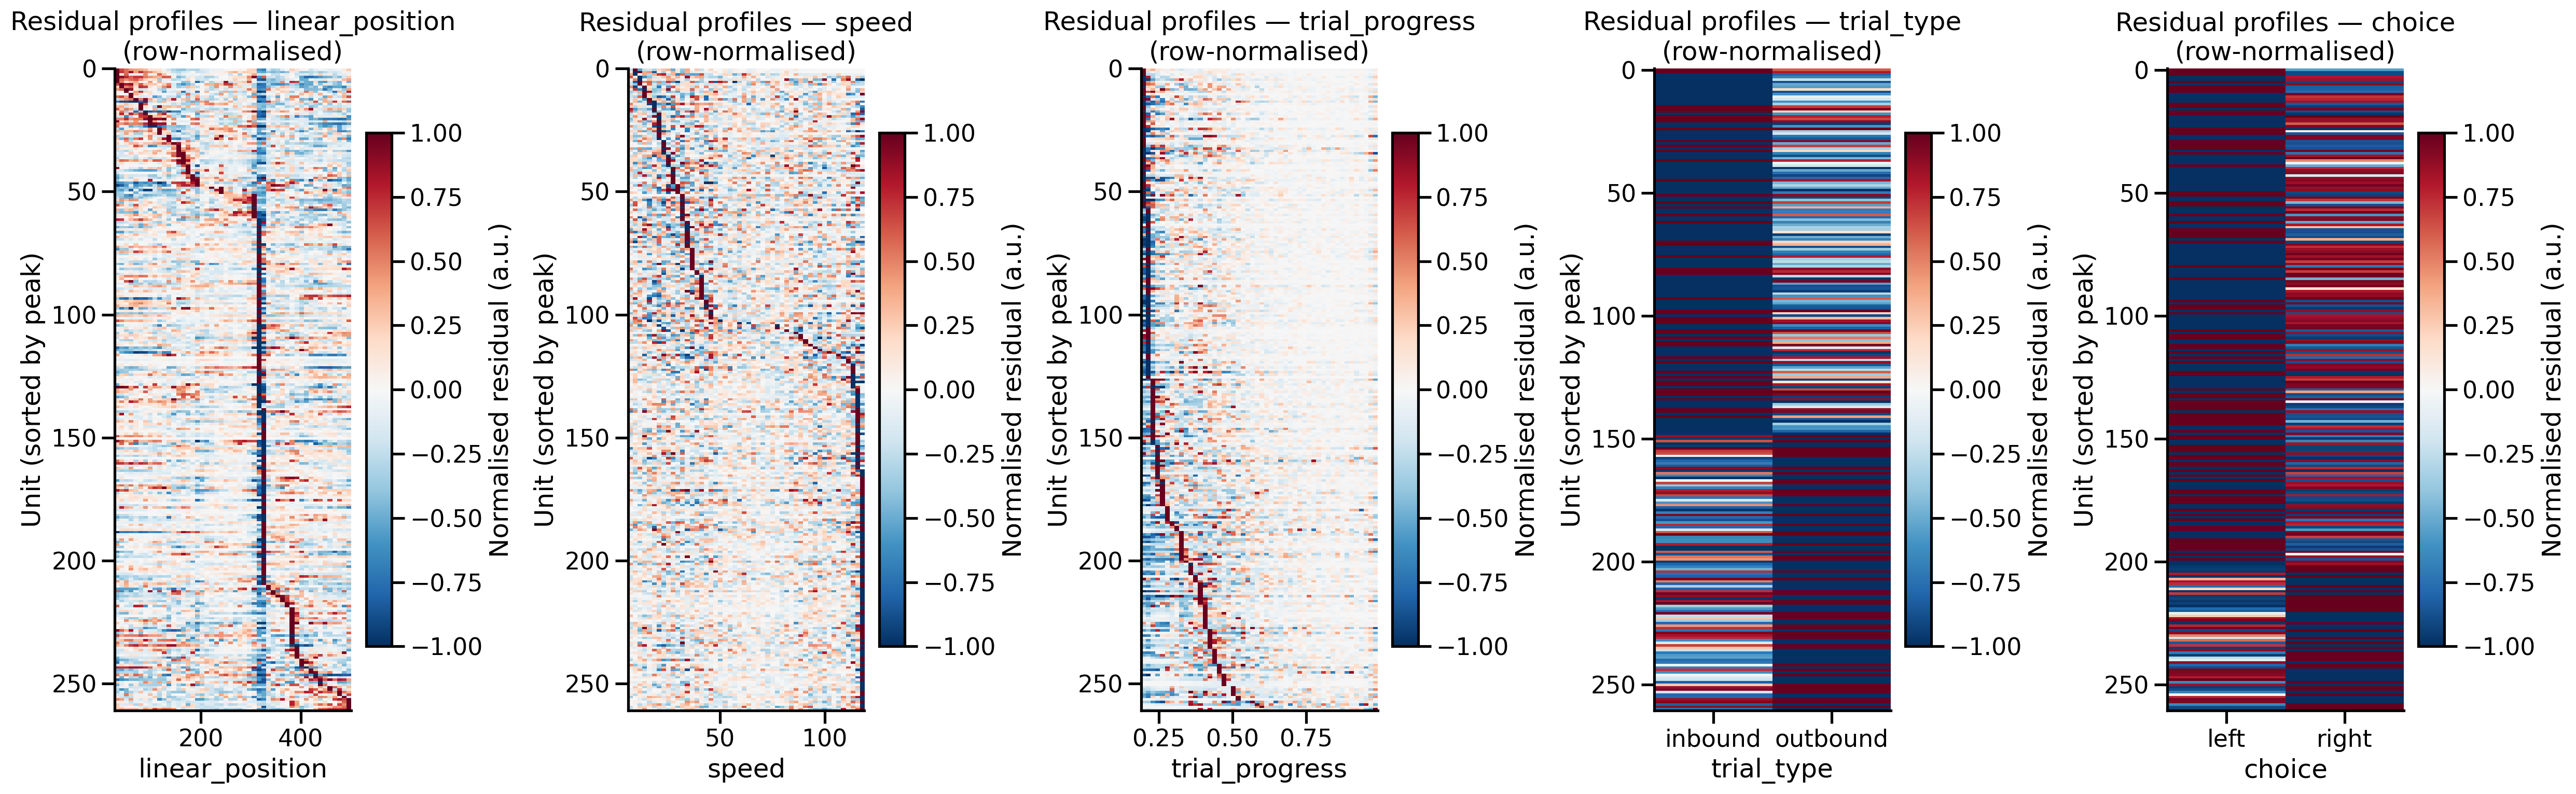

In [127]:
plot_residual_heterogeneity(prof_temporal)

## Model comparison

### Single-variable

In [129]:
from scipy.stats import chi2

# Load all model CSVs
model_files = {
    "null":                    (f"{base_dir}/analysis/null_model_all.csv",                    dict(keep_default_na=False, na_values=[""])),
    "null_out":                (f"{base_dir}/analysis/null_out_model_all.csv",                dict(keep_default_na=False, na_values=[""])),
    "trial_type":              (f"{base_dir}/analysis/trial_type_model_all.csv",              {}),
    "choice":                  (f"{base_dir}/analysis/choice_model_all.csv",                  {}),
    "speed_spline":            (f"{base_dir}/analysis/speed_spline_model_all.csv",            {}),
    "pos_spline":              (f"{base_dir}/analysis/pos_spline_model_all.csv",              {}),
    "trial_progress_spline":   (f"{base_dir}/analysis/trial_progress_spline_model_all.csv",  {}),
    "temporal_model_all":      (f"{base_dir}/analysis/temporal_model_all.csv",               {}),
    "full_model_all":          (f"{base_dir}/analysis/full_model_all.csv",                   {}),
    
}

models = {}
for name, (path, kwargs) in model_files.items():
    df = pd.read_csv(path, index_col=0, **kwargs)
    df["model"] = name
    models[name] = df.set_index("unit")

# Null baseline per model — must match the dataset the model was fit on
null_for = {
    "trial_type":            "null",
    "speed_spline":          "null",
    "pos_spline":            "null",
    "trial_progress_spline": "null",
    "choice":                "null_out",
    "temporal_model_all":    "null",
    "full_model_all":        "null",
}

rows = []
for model_name, null_name in null_for.items():
    m   = models[model_name]
    nul = models[null_name]

    for uid in m.index:
        row      = m.loc[uid]
        null_row = nul.loc[uid]

        lrt_stat = 2 * (row["llf"] - null_row["llf"])
        lrt_df   = int(row["df_model"]) if pd.notna(row["df_model"]) else 0
        lrt_pval = (1 - chi2.cdf(lrt_stat, lrt_df)) if lrt_df > 0 else np.nan

        rows.append(dict(
            unit        = uid,
            model       = model_name,
            aic         = row["aic"],
            llf         = row["llf"],
            n_params    = row["n_params"],
            n_obs       = row["n_obs"],
            converged   = row["converged"],
            delta_aic   = row["aic"] - null_row["aic"],
            lrt_stat    = lrt_stat,
            lrt_df      = lrt_df,
            lrt_pval    = lrt_pval,
            tuned       = bool(lrt_pval < 0.05) if not np.isnan(lrt_pval) else False,
        ))

comparison = pd.DataFrame(rows)

summary = comparison.groupby("model").agg(
    mean_dAIC  = ("delta_aic", "mean"),
    median_dAIC= ("delta_aic", "median"),
    n_tuned    = ("tuned",     "sum"),
    frac_tuned = ("tuned",     "mean"),
    n_converged= ("converged", "sum"),
).round(3)
print(summary)

                           mean_dAIC    median_dAIC  n_tuned  frac_tuned  \
model                                                                      
choice                 -82.007000000  -17.163000000      197 0.749000000   
full_model_all        -537.947000000 -354.903000000      259 0.985000000   
pos_spline            -240.869000000 -141.534000000      250 0.951000000   
speed_spline          -238.277000000 -119.521000000      252 0.958000000   
temporal_model_all    -532.155000000 -292.211000000      260 0.989000000   
trial_progress_spline -365.011000000 -170.226000000      251 0.954000000   
trial_type             -54.171000000  -14.389000000      197 0.749000000   

                       n_converged  
model                               
choice                         262  
full_model_all                 258  
pos_spline                     259  
speed_spline                   262  
temporal_model_all             261  
trial_progress_spline          261  
trial_type         

In [ ]:
# Pivot to wide AIC table : enables direct pairwise model comparison
aic_wide = comparison.pivot(index="unit", columns="model", values="aic")

# Add null baselines 
aic_wide["null"]     = models["null"]["aic"]
aic_wide["null_out"] = models["null_out"]["aic"]

# Best single-variable model per unit (all-trials models only)
all_trials_models = ["trial_type",  "speed_spline", "pos_spline", "trial_progress_spline", "temporal_model_all", "full_model_all"]
aic_wide["best_model"] = aic_wide[all_trials_models].idxmin(axis=1)
print("Best model counts (all units):")
print(aic_wide["best_model"].value_counts())

Best model counts (all units):
best_model
full_model_all           146
temporal_model_all       108
pos_spline                 5
trial_progress_spline      2
speed_spline               1
Name: count, dtype: int64


/tmp/ipykernel_225552/2944036466.py:10: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  aic_wide["best_model"] = aic_wide[all_trials_models].idxmin(axis=1)


In [136]:
# which model has the highest mean delta-AIC?
model_cols = ["trial_type","speed_spline", "pos_spline", "trial_progress_spline"]
delta_aic = aic_wide[model_cols].subtract(aic_wide["null"], axis = 0)
print(delta_aic.mean(axis=0))
print("model with max delta aic: ", min(delta_aic.mean(axis = 0)))

model
trial_type               -54.170544942
speed_spline            -238.276558978
pos_spline              -240.868942153
trial_progress_spline   -365.011004551
dtype: float64
model with max delta aic:  -365.01100455123833


In [140]:
#full model improvement over null
glm_full = pd.read_csv(f"{base_dir}/analysis/full_model_all.csv", index_col=0)
glm_full = glm_full[glm_full["converged"] == True].copy()

df_model  = glm_full["n_params"] - 1                              # degrees of freedom vs null
lrt_stat  = glm_full["deviance_null"] - glm_full["deviance"]      # 2*(llf_full - llf_null)
lrt_pval  = 1 - chi2.cdf(lrt_stat, df_model)                      # per-unit p-value

n_sig  = (lrt_pval < 0.05).sum()
_, pop_pval = wilcoxon(lrt_stat, zero_method="wilcox", alternative="greater")  # population: LRT > 0?

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

# Panel A: LRT statistic distribution
ax = axes[0]
ax.hist(lrt_stat, bins=40, color="steelblue", edgecolor="none", alpha=0.8)
ax.axvline(lrt_stat.median(), color="orange", lw=1.5,
           label=f"median = {lrt_stat.median():.1f}")
ax.set_xlabel("LRT statistic")
ax.set_ylabel("Number of units")
ax.set_title(f"LRT: full vs null  (n={len(lrt_stat)} units)\nWilcoxon p = {pop_pval:.2e}")
ax.legend(fontsize=9)
sns.despine(ax=ax)

# Panel B: per-unit p-value histogram
ax = axes[1]
ax.hist(lrt_pval, bins=40, color="steelblue", edgecolor="none", alpha=0.8)
ax.axvline(0.05, color="red", lw=1.5, ls="--", label="p = 0.05")
ax.set_xlabel("Per-unit LRT p-value")
ax.set_ylabel("Number of units")
ax.set_title(f"{n_sig}/{len(lrt_pval)} units significant (p < 0.05)")
ax.legend(fontsize=9)
sns.despine(ax=ax)


### Drop-one & LRT (combined models)

In [141]:
datasets = {
    "common":   (cov_df_common, spike_counts_common),
    "outbound": (cov_df_out_common, spike_counts_out_common),
}

drop_one_specs = make_drop_one_specs(
    datasets=datasets,
    model_names=["full_model", "temporal_model"],
)

In [143]:
#check_if_exists=True skips already-saved CSVs
for model_name in drop_one_specs:
    run_drop_one_suite(drop_one_specs, model_name, base_dir, unit_ids, check_if_exists=True)


Running drop-one suite: full_model_all(3 fits)
    Skipping trial_type - file exists
    Skipping bs(pos_scaled, df=8) - file exists
    Skipping bs(speed_scaled, df=4) - file exists

Running drop-one suite: temporal_model_all(3 fits)
    Skipping trial_type - file exists
    Skipping cr(trial_progress, df=6, constraints='center') - file exists
    Skipping bs(speed_scaled, df=4) - file exists


In [144]:
# Compute LRT for all models and concatenate 
lrt_frames = [compute_drop_one_lrt(model_name, base_dir, drop_one_specs) for model_name in drop_one_specs]
drop_one_results = pd.concat(lrt_frames, ignore_index=True)

print(drop_one_results.shape)


  [full_model_all drop=trial_type] skipped 6 units (non-converged)
  [full_model_all drop=bs(pos_scaled, df=8)] skipped 5 units (non-converged)
  [full_model_all drop=bs(speed_scaled, df=4)] skipped 5 units (non-converged)
  [temporal_model_all drop=trial_type] skipped 2 units (non-converged)
  [temporal_model_all drop=cr(trial_progress, df=6, constraints='center')] skipped 2 units (non-converged)
  [temporal_model_all drop=bs(speed_scaled, df=4)] skipped 2 units (non-converged)
(1556, 9)


In [146]:
# Summary table 
summary_drop = (
    drop_one_results
    .groupby(["model", "dropped_term"])
    .agg(
        n_units          = ("unit",        "count"),
        n_significant    = ("significant", "sum"),
        frac_significant = ("significant", "mean"),
        mean_delta_aic   = ("delta_aic",   "mean"),
        median_delta_aic = ("delta_aic",   "median"),
    )
    .round(3)
)
print(summary_drop.to_string())

# Short labels for plotting 
term_labels = {
    "trial_type": "trial_type",
    "choice":     "choice",
    "bs(pos_scaled, df = 8)":                             "position",
    "bs(speed_scaled, df = 4)":                           "speed",
    "cr(trial_progress, df = 6, constraints = 'center')": "trial_progress",
}
plot_df = drop_one_results.copy()
plot_df["term_label"] = plot_df["dropped_term"].map(term_labels).fillna(plot_df["dropped_term"])

summary_plot = (
    plot_df.groupby(["model", "term_label"])
    .agg(frac_significant=("significant", "mean"), mean_delta_aic=("delta_aic", "mean"))
    .round(3)
)

# Figure: fraction significant + mean delta AIC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
summary_plot["frac_significant"].unstack("term_label").plot.barh(ax=ax)
ax.axvline(0.05, color="red", lw=1, ls="--", label="α=0.05")
ax.set_xlabel("fraction of units (LRT p < 0.05)")
ax.set_title("Unique contribution: fraction significant")
ax.legend(title="dropped term", fontsize=8, loc="lower right")
sns.despine(ax=ax)

ax = axes[1]
summary_plot["mean_delta_aic"].unstack("term_label").plot.barh(ax=ax)
ax.axvline(0, color="black", lw=0.8, ls="--")
ax.set_xlabel("mean ΔAIC (full − reduced)\nnegative = full model better")
ax.set_title("Unique contribution: effect size (AIC)")
ax.legend(title="dropped term", fontsize=8, loc="lower right")
sns.despine(ax=ax)

plt.tight_layout()

# Figure: per-unit delta AIC distributions 
g = sns.FacetGrid(plot_df, col="model", col_wrap=2, height=4, sharey=False, sharex=False)
g.map_dataframe(
    sns.boxplot, x="delta_aic", y="term_label",
    color="steelblue", width=0.5, flierprops=dict(marker=".", ms=3)
)
g.map(plt.axvline, x=0, color="red", lw=1, ls="--")
g.set_axis_labels("ΔAIC (full − reduced)", "dropped term")
g.set_titles("{col_name}")
sns.despine()
plt.tight_layout()

                                                                   n_units  n_significant  frac_significant  mean_delta_aic  median_delta_aic
model              dropped_term                                                                                                              
full_model_all     bs(pos_scaled, df=8)                                258            252       0.977000000  -254.448000000    -147.207000000
                   bs(speed_scaled, df=4)                              258            243       0.942000000  -248.914000000    -105.285000000
                   trial_type                                          257            187       0.728000000   -49.237000000     -13.582000000
temporal_model_all bs(speed_scaled, df=4)                              261            246       0.943000000  -111.314000000     -52.404000000
                   cr(trial_progress, df=6, constraints='center')      261            249       0.954000000  -241.761000000    -109.607000000
      

/home/labuser/miniforge3/envs/spyglass/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  self._figure.tight_layout(*args, **kwargs)
/home/labuser/miniforge3/envs/spyglass/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  self._figure.tight_layout(*args, **kwargs)
/tmp/ipykernel_225552/2243567977.py:64: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


### Statistical summary

In [147]:
# FDR correction : 
drop_one_results = apply_fdr_correction(drop_one_results)


In [148]:
# Pairwise comparison : run for each combined model
pw_full     = pairwise_term_comparison(drop_one_results, 'full_model_all')
pw_temporal = pairwise_term_comparison(drop_one_results, 'temporal_model_all')

print('Full model pairwise q-values:')
print(pw_full.round(3).to_string())


Full model pairwise q-values:
                        bs(pos_scaled, df=8)  bs(speed_scaled, df=4)  trial_type
bs(pos_scaled, df=8)                     NaN             0.003000000 0.000000000
bs(speed_scaled, df=4)           0.003000000                     NaN 0.000000000
trial_type                       0.000000000             0.000000000         NaN


In [149]:
plot_drop_one_summary(drop_one_results, pairwise_pvals=pw_full,
                      heatmap_model='full_model_all')


## Visualization

### Place field maps (position spline)

### Place field maps from pos_spline

In [154]:
import ast
from patsy import dmatrix

#  shared prediction infrastructure 
pos_pred_vals = np.linspace(pos_min_val, pos_max_val, 300)
pos_pred_scaled = (pos_pred_vals - pos_min_val) / (pos_max_val - pos_min_val)

# Fit reference unit to capture patsy's design_info (knot placement)
_ref = cov_df_common[["pos_scaled"]].copy()
_ref["spike_count"] = spike_counts_common[0]
_ref_fit = smf.glm("spike_count ~ bs(pos_scaled, df=8)", data=_ref, family=sm.families.Poisson()).fit()

X_pred = np.array(dmatrix(_ref_fit.model.data.design_info,
                           pd.DataFrame({"pos_scaled": pos_pred_scaled})))

# Parse stored coefficients — eval() handles bare `nan` tokens that ast.literal_eval rejects
_NAN_NS = {"nan": float("nan")}

def _rate_curve(row):
    if not isinstance(row["coef"], str):
        return np.full(len(pos_pred_vals), np.nan)
    coefs = np.array(list(eval(row["coef"], _NAN_NS).values()))
    if np.any(np.isnan(coefs)):
        return np.full(len(pos_pred_vals), np.nan)
    return np.exp(X_pred @ coefs) / BIN_SIZE

rate_matrix = np.vstack([_rate_curve(r) for _, r in pos_spline_model_all.iterrows()])

# Peak position : NaN for units whose fit failed (all-NaN row)
valid_units = ~np.isnan(rate_matrix).all(axis=1)
peak_pos_cm = np.full(len(rate_matrix), np.nan)
peak_pos_cm[valid_units] = pos_pred_vals[np.argmax(rate_matrix[valid_units], axis=1)]

# Track projection data (downsampled) : used by all track plots
pos_run = trialized_position[trialized_position["zone"] == "run"][
    ["linear_position", "projected_x_position", "projected_y_position"]
].dropna().iloc[::5].copy()
pos_run["pos_scaled"] = (pos_run["linear_position"] - pos_min_val) / (pos_max_val - pos_min_val)
pos_run = pos_run[(pos_run["pos_scaled"] >= 0) & (pos_run["pos_scaled"] <= 1)]

n_failed = (~valid_units).sum()
print(f"rate_matrix: {rate_matrix.shape}  ({n_failed} units failed/skipped)")
print(f"peak positions range: {np.nanmin(peak_pos_cm):.0f} – {np.nanmax(peak_pos_cm):.0f} cm")

#  initialise plot state for encoding_utils plot functions 
set_plot_state(rate_matrix, pos_pred_vals, pos_run, peak_pos_cm)

rate_matrix: (263, 300)  (4 units failed/skipped)
peak positions range: 24 – 506 cm


#### 1. Single unit

In [157]:
# plot_place_field
selected_unit = 12
plot_place_field(selected_unit)

#### 2. Grid of selected units

In [158]:
# plot_place_field_grid 
grid_units = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
plot_place_field_grid(grid_units, ncols=4)

#### 3. Population summary (all units)

In [ ]:
#  population heatmap: valid units only, sorted by peak position
valid_idx = np.where(valid_units)[0]
sort_order = valid_idx[np.argsort(peak_pos_cm[valid_idx])]

rate_sorted = rate_matrix[sort_order]
rate_norm = (rate_sorted - rate_sorted.min(axis=1, keepdims=True)) / \
            (rate_sorted.max(axis=1, keepdims=True) - rate_sorted.min(axis=1, keepdims=True) + 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im = axes[0].imshow(rate_norm, aspect="auto", origin="lower", cmap="hot_r",
                    extent=[pos_pred_vals[0], pos_pred_vals[-1], 0, len(sort_order)])
plt.colorbar(im, ax=axes[0], label="normalised rate")
axes[0].set_xlabel("linear position (cm)")
axes[0].set_ylabel(f"unit (sorted by peak,  n={len(sort_order)})")
axes[0].set_title("Population place fields")

axes[1].hist(peak_pos_cm[valid_idx], bins=30, color="steelblue", edgecolor="white")
axes[1].set_xlabel("peak position (cm)")
axes[1].set_ylabel("unit count")
axes[1].set_title("Distribution of place field peaks")
sns.despine(ax=axes[1])

plt.tight_layout()